<div style="max-width: 900px; text-align: justify;">

<img src="https://raw.githubusercontent.com/rmpt-phys/Test-Repo-Images/main/iFast.png" width="350" align="center">
<img src="https://raw.githubusercontent.com/rmpt-phys/Test-Repo-Images/main/cemaden.png" width="350" align="center">

</div>

<div style="max-width: 900px; text-align: justify;">

#### **About this notebook**

A general notebook developed for reading, analyzing, pre-processing rain-gauge / river-stage data and flash-flood modeling with detailed analysis of performance and predictions of machine-leaning algorithms.<br> 

The notebook loads all station-separated files, aligns them on a unified 10-minute time grid, and inserts NaNs where measurements are missing. It then performs a set of analyses to extract and summarize key characteristics of the time series from each station. A curated collection of data frames is produced, including only stations that are active and meet predefined data-quality criteria.<br>

River-stage records undergo a two-step pre-processing pipeline: first, outliers are identified and removed using the Hampel filter; second, a zero-phase low-pass filter is applied to obtain smooth, noise-reduced time series. Rainfall data are treated with a different procedure, appropriate for their discrete and event-driven nature.<br>

The resulting processed rain-gauge and river-stage data are exported as well-structured CSV files, and dedicated training datasets are generated for use within the ML4FF framework. This notebook also provides a step-by-step guide for producing stage forecasting models with this framework and also for analyzing their performance and predictions.<br>

**Code author:**

<pre>
- Rafael Marques Paes Teixeira 
- Orcid: 0000-0001-7290-3573
</pre>
<br>
Important contributions to this notebook were made by:

<pre>
- Leonardo Bacelar Lima Santos (project manager)
- Orcid: 0000-0002-3129-772X
</pre>
<br>
Collaborators that contributed with important codes, data and discussions:

<pre>
- Andrea S. Viteri López     (0000-0002-9929-391X)
- Lidiane S. Lima            (0000-0001-5490-3975)
- Elton V. Escobar Silva     (0000-0002-9437-9351)
- Jaqueline A. J. P. Soares  (0000-0002-2569-7620)
- Kleber L. Rocha-Filho      (0009-0001-7558-1108)
- Glauston R. T. Lima        (0000-0002-6854-7921)
- Cristiano W. Eichholz      (0000-0001-7123-5438)
</pre>
<br>

**Contact emails:** rafael.mpt@gmail.com, santoslbl@gmail.com

---

#### **Preparations for the complete execution of this notebook**

The ML4FF framework and the needed data to reproduce the results presented and analyzed in this notebook can be obtained from the links below:

https://zenodo.org/records/17654660

https://github.com/jaqueline-soares/ML4FF-framework

</div>

<!-- Abstract and Author's short-bio -->

<div style="max-width: 900px; text-align: justify;">

---

#### **Abstract**

Accurate flash-flood forecasting in urban watersheds requires rainfall information that captures both spatial structure and rapid variability. While rain gauges provide valuable point measurements, they often fail to represent basin-scale precipitation. Weather radar, in contrast, offers high-resolution spatial fields but includes its own sources of uncertainty. To evaluate the predictive value of each source, we trained machine-learning river-stage models using two setups -- one driven by gauge-based rainfall and another driven by radar-derived rainfall -- using a curated 10-year hydrometeorological dataset (10-min resolution, 23 gauges, 1-km radar fields) and the ML4FF (Machine Learning for Flash Floods) cross-validated training framework. Two algorithms -- XGBRegressor, representing tree-based methods, and LinearSVR, representing support-vector regression -- were selected as methodological representatives. Both achieved strong hydrological performance in the two rainfall setups, with high Nash-Sutcliffe Efficiency (NSE) and Kling-Gupta Efficiency (KGE) across multiple lead times up to 2 hours, and showed excellent agreement with observations. In particular, the models displayed high linear correlation ($R^{2}$), indicating close similarity between predicted and observed stage distributions. Their robustness was confirmed during an extreme event, successfully reproducing the ~7 m rapid rise of a major flood episode analyzed in detail. The complete dataset, together with all preprocessing and filtering procedures used to prepare the time series, is openly released to support the development and benchmarking of ML-based early-warning systems.

---

#### **Author's short-bio**

Computational physicist with a strong focus on numerical modeling and high-performance scientific computing. I develop and optimize simulation codes in C++ and Fortran, leveraging OpenMPI for scalable execution on HPC systems, and use Python (and occasionally R) for data analysis, visualization, and rapid prototyping.

My background includes nonlinear dynamics (numerical solutions of PDEs), condensed matter physics, and statistical physics. I have implemented and applied a range of simulation techniques, including classical and quantum Monte Carlo (MC/QMC), semiclassical molecular dynamics (SMD), and spin models (Ising, Heisenberg, spin-fermion systems) on periodic and disordered lattices. My work often involves building custom simulation frameworks from scratch, with attention to numerical stability, performance, and reproducibility.

More recently, I have expanded into data-driven modeling, working with large-scale time series and machine learning methods for forecasting problems. I am particularly interested in hybrid approaches that combine physical constraints with learning algorithms, such as Physics-Informed Neural Networks (PINNs) and Neural Operators (PINOs), aiming at efficient simulation, inverse problems, and super-resolution in complex systems.

</div>

<!-- Problem Statement and Motivation, Quick Literature Review, Study Approach -->

<div style="max-width: 900px; text-align: justify;">

---

#### **Problem Statement and Motivation**

Flash floods in urban watersheds pose severe risks, driven by intense and spatially heterogeneous rainfall that can rapidly exceed the capacity of drainage systems -- especially in densely urbanized regions with impervious surfaces and altered hydrological response. Rain gauges provide accurate point-scale measurements but often fail to represent basin-scale rainfall variability. Weather radar, by contrast, offers high-resolution spatial fields capable of capturing storm structure, but its effective use is challenged by uncertainties in calibration, data quality, and limited long-term availability in countries such as Brazil.

Traditional physics-based hydrological and hydrodynamic models require extensive calibration, high-quality basin characterization, and large computational resources, which can limit their use in real-time early-warning systems. Machine learning (ML) offers an alternative by learning nonlinear rainfall-runoff relationships directly from data, potentially improving lead-time performance under sparse or heterogeneous observational conditions [1].

---

#### **Quick Literature Review**

ML-based hydrological modeling has grown rapidly as a complement or alternative to conceptual and physics-based models. Methods such as LSTM networks and boosting algorithms (e.g., XGBoost, LightGBM) frequently outperform traditional models for short-lead flood forecasting (1-6 hours). However, performance varies widely among watersheds, and no single method generalizes optimally across all hydrological regimes, underscoring the need for systematic benchmarking.

Despite its potential, the use of weather radar in ML hydrology remains relatively limited. Many studies rely exclusively on rain gauges because radar archives are often unavailable, short, or inconsistent, particularly in regions with data scarcity. This gap motivates direct comparisons between gauge-based and radar-based rainfall inputs in ML-approach flood forecasting.

A recent radar-based modeling example is the ANN study from Ref. [2], which used high-resolution radar rainfall to drive a feed-forward neural network for flash-flood forecasting. The ANN achieved satisfactory performance (NSE > 0.6) when rainfall was accumulated over at least 2 hours, highlighting the importance of temporal aggregation and radar input quality when predicting fast watershed responses. This reinforces the broader view that radar can improve ML hydrological modeling when appropriately processed.

In this context, Ref. [3] introduces the ML4FF framework, which provides an integrated and systematic machine-learning methodology encompassing 34 algorithms across 11 methodological classes. The framework implements a multi-metric evaluation strategy that reports standard hydrological performance measures, computational efficiency, and optimized (fine-tuned) hyperparameter configurations for every model. Ref. [3] presents a comprehensive benchmarking study using rigorous nested cross-validation for a highly flood-prone urban watershed in Brazil. The top-performing models -- including LSTM, LGBMRegressor, and NuSVR -- achieved NSE ≥ 0.80 and KGE ≈ 0.90 for lead times up to 120 minutes, demonstrating that high predictive skill can be reached using purely data-driven approaches. The ML4FF framework further underscores the importance of transparent benchmarking practices and diverse model evaluation for developing reliable ML-based early-warning systems.

---

#### **Study Approach**

Motivated by these gaps and opportunities, the present study benchmarks ML river-stage forecasting models using a novel 10-year hydrometeorological dataset composed of 23 rain gauges, 1-km weather-radar fields, and 10-minute temporal resolution. The study area is the Tamanduateí River Watershed (TRW), located in the São Paulo Metropolitan Region, Brazil. Rainfall data were collected from 23 tipping-bucket automatic gauges (0.2 mm resolution, 10-minute intervals), all part of the Alto Tietê telemetric network and managed by the São Paulo Flood Warning System (SAISP). Stage observations were obtained from automatic station 413, which also measures rainfall.

Radar-derived precipitation was obtained from a dual-polarization S-band Doppler radar (SPOL), situated in eastern São Paulo state and covering approximately 181000 $\text{km}^{2}$. The radar performs volumetric scans in two modes: a surveillance mode with two elevation angles every 15 minutes, and an operational mode with seven elevation angles every 5 minutes. Radar rainfall fields were aggregated into 10-minute intervals under an assumption of steady precipitation between scans.

The spatial distribution of rain gauges is shown in panel (C) of the figure below (credits: Elton V. Escobar), while panel (B) illustrates the radar coverage area.

<img src="https://raw.githubusercontent.com/rmpt-phys/Test-Repo-Images/main/TRW_Gauge_Map.png" width="900" align="center">

We use the ML4FF framework, which manages the entire ML modeling pipeline for flash flood forecasting (code author: Jaqueline A. J. P. Soares, technologist at CEMANDEN; GitHub link: https://github.com/jaqueline-soares/ML4FF-framework). We perform ML experiments to compare two rainfall-input setups:

1. Gauge-based rainfall;
2. Radar-based rainfall;

Two algorithms representative of distinct ML families are evaluated:

* XGBRegressor (tree-based ensemble learning);
* LinearSVR (support-vector regression);

The results show that both models achieved strong hydrological performance across both rainfall setups. High Nash-Sutcliffe Efficiency (NSE) and Kling-Gupta Efficiency (KGE) values were obtained for lead times up to 2 hours, accompanied by strong linear correlation ($R^{2}$) and very small Wasserstein distances between predicted and observed river-stage distributions. The models also demonstrated operational robustness by accurately reproducing the approximately 7 m rapid rise observed during an extreme flash-flood event analyzed in detail.

All preprocessing and time-series filtering procedures -- including gauge--radar alignment, data-quality screening, Hampel outlier detection, and zero-phase low-pass filtering -- are released with the curated dataset to support transparent benchmarking and reproducible ML-based early-warning development.

---

#### **References**

[1] Santos, L. B. L., Escobar-Silva, E. V., Satolo, L. F., Oyarzabal, R. S., Diniz, M. M., Negri, R. G., Lima, G. R. T., Stephany, S., Soares, J. A. J. P., Duque, J. S., Saraiva Filho, F. L., Caseri, A. N., & Bacelar, L. (2025). *Machine learning-based hydrological models for flash floods: A systematic literature review.* Smart Construction and Sustainable Cities, 3, 21. https://doi.org/10.1007/s44268-025-00071-9​​

[2] Santos, L. B. L., Freitas, C. P., Bacelar, L., Soares, J. A. J. P., Diniz, M. M., Lima, G. R. T., & Stephany, S. (2023). *A Neural Network-Based Hydrological Model for Very High-Resolution Forecasting Using Weather Radar Data.* Eng, 4(3), 101. https://doi.org/10.3390/eng4030101

[3] Soares, J. A. J. P., Ozelim, L. C. S. M., Bacelar, L., Ribeiro, D. B., Stephany, S., & Santos, L. B. L. (2025). *ML4FF: A machine-learning framework for flash flood forecasting applied to a Brazilian watershed.* Journal of Hydrology. https://doi.org/10.1016/j.jhydrol.2025.132674

</div>

<div style="max-width: 900px; text-align: justify;">

### **Part 1**

---

### **From raw gauge measurements to unified hydrometeorological datasets:<br>a guide to data cleaning, filtering, and preparation for flash-flood modeling**

</div>

#### **Data acquisition and general pre-processing:**

1. Prepare conda environment for the notebook;
2. Load required Python libraries for full execution;
3. Read stage and/or rainfall measurements from all stations data-files;
4. Pre-process all time-series and make report summary for all files;
5. Select active stations during the 10-years period of interest;

**Prepare conda environment for the notebook:**

1. Go the notebook directory to find the provided yml-file ("conda_env.yml");<br>

2. Open a terminal/prompt and create the conda environment "ml4ff_env":
* conda env create -f conda_env.yml<br>
* conda activate ml4ff_env<br>

3. Before (2), one can change the name of the environment if desired;

**Load required Python libraries for full execution**:

In [1]:
# Basic utilities

import os
import re
import textwrap
import numpy as np
import pandas as pd

# Plotting libraries

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker

from matplotlib.lines import Line2D
from matplotlib.collections import LineCollection
from matplotlib.offsetbox import AnchoredText

# Statistics & signal processing tools

from sklearn.metrics import r2_score

from scipy import stats, signal

from scipy.signal import welch

from scipy.stats import (
    pearsonr,
    ks_2samp,
    linregress,
    gaussian_kde,
    wasserstein_distance,    
)

from statsmodels.distributions.empirical_distribution import ECDF

from hampel import hampel

# Other utilities

import seaborn as sns

from tabulate import tabulate

<div style="max-width: 900px; text-align: justify;">

**Read stage and/or rainfall measurements from all stations data-files:**

All rainfall + stage data from gauges and also the rainfall estimates derived from radar fields were provided by Kleber L. Rocha-Filho (meteorologist/technologist at CEMADEN). Here, we assume that the data-files can be found in *Telemetric_Time_Series_Data_TRW* within in the same notebook directory (**important: unzip the folder before running the next cell**). There, we expect to find CSV files containing time-series data, i.e., a time-stamp column (expected name: "DATA") and data columns (expected names: FLUm, PLUmm). For the given dataset, the river level (stage) data comes from columns named "FLUm" (fluviômetro, unidade: metros) and the rainfall data derived from *in situ* gauge measurements comes from columns named "PLUmm" (pluviômetro, unidade: milímetros). In this notebook, we do not consider radar-derived rainfall data, contact the collaborators Andrea S. Viteri López and Lidiane S. Lima for more information;

</div>

In [2]:
# Path to data-files

path = "Telemetric_Time_Series_Data_TRW/"

# List with all files in the directory

files = os.listdir(path)

# Extract station number from filenames

numbers = []

for f in files:
    ##
    match = re.findall(r"\d+", f) #( find all numbers )

    if match: numbers.extend([int(num) for num in match])

# Make initial list (version 0) with stations sorted in descending order

stationsV0 = sorted(numbers, reverse = False)

print(f"Found files for {len(stationsV0)} stations!\n")

# We can see the list of stations as follows:

print("\n".join(textwrap.wrap(", ".join(map(str, stationsV0)), width = 28)))

Found files for 37 stations!

143, 275, 279, 280, 283,
413, 511, 563, 629, 730,
731, 810, 836, 1000132,
1000133, 1000350, 1000370,
1000390, 1000400, 1000410,
1000420, 1000430, 1000490,
1000500, 1000510, 1000530,
1000550, 1000580, 1000590,
1000600, 1000610, 1000780,
1000837, 1000839, 1000867,
1000958, 1000959


* Now, let us define strings with the names of the main columns within these data-files:

In [3]:
colF = "FLUm"  # Data column names
colP = "PLUmm" # with FLU/PLU values

* We can define custom names for the temporal columns<br>
(time-stamps and years) to be used in the output CSV files:

In [4]:
col_time = "time-stamp" # Data column names for
col_year = "year"       # time-stamps and year

* The data-files are named as follows: "P_N_INST.csv", N: station number;<br>

* Below, we read each CSV file in a loop while applying some procedures:
1. Parse timestamps (we keep only data registered from 2015 onwards);
2. During (1), a year-column is added (*col_year*) and the time-stamp column renamed (*col_time*);
3. Drop NaNs (not a number) at any time-stamp and round time-stamps to nearest 10 minutes grid-point;
4. Step (3) may produce measurements with repeating time-stamps, we deal with them in (5) below;
5. Define aggregation rule to deal repeating time-stamps: take the average of numerical values;
6. Apply grouping + aggregation: values from repeating time-stamps converge to a single averaged value;
7. Make uniform 10-minute time-series by filling missing time-stamps with NaNs;
8. The resulting series are assigned to a collection of data-frames: dfs[N = 0,1,2,...,36];
9. Find stations exceeding 10% of NaNs (see variable *tval*), these are flagged as *bad stations*;

10. Summarize the whole process with a table (look for the panda data-frame *df_summary*) containing:<br>
first and final time-stamps, number of time-stamps rounded, percent of NaNs, number of rows/columns;

In [5]:
dfs = {} # Dictionary to store all data-frames

summary = [] # Summary list to append information

FLU_subset = [] # List containing the
PLU_subset = [] # stations with FLU and/or PLU

BAD_FLU_subset = [] # Bad FLU list
BAD_PLU_subset = [] # Bad PLU list

tval = 10 #( threshold for flagging as bad / percent )

for st in stationsV0:
    ##
    #---------
    # Read CSV

    filename = f"P_{st}_INST.csv"

    df = pd.read_csv(path + filename)

    #----------------------------------------------------
    # Parse timestamps (keep only data from 2015 onwards)

    df.rename(columns={"DATA": col_time}, inplace = True)

    df[col_time] = pd.to_datetime(df[col_time],
                                  errors = "coerce", format = "mixed")

    df[col_year] = df[col_time].dt.year

    df = df[df[col_year] >= 2015].copy()

    nrows_before = len(df) #( before grouping )

    #--------------------------------------------------------
    # Drop invalid and round timestamps to nearest 10 minutes

    df = df.dropna(subset = [col_time])

    df[col_time] = df[col_time].dt.round("10min")

    #-------------------------------------------------------
    # Define aggregation rules to deal repeating time-stamps

    agg_rules = {}

    for col in df.columns:
        ##
        if col == col_time: continue

        if pd.api.types.is_numeric_dtype(df[col]):
            ##
            agg_rules[col] = "mean"  # average numeric values
        else:
            agg_rules[col] = "first" # keep first non-numeric 

    #-----------------------------
    # Apply grouping + aggregation

    df = df.groupby(col_time, as_index = False).agg(agg_rules)

    nrows_after = len(df) #( after grouping )

    nrowsDel = nrows_before - nrows_after    

    #-----------------------------------------------
    # Apply pre-processing: fill missing time-stamps 
    # (additional NaNs at FLUm and/or PLUmm columns)
    #
    # 1) Create full 10-minute index;
    #
    # 2) Reindex the data-frame to include all timestamps;
    #
    # 3) Drop columns "Posto" and col_year (recompute it);
    #
    # 4) Save to combined data-frames (dfs);

    start_date = df[col_time].iloc[ 0]
    final_date = df[col_time].iloc[-1]

    full_index = pd.date_range(start_date, final_date, freq = "10min")

    df = (df
        .set_index(col_time)   # make col_time as the data-frame index
        .reindex(full_index)   # align index to the full 10-minute index
        .rename_axis(col_time) # rename index column as col_time and reset
        .reset_index()         # index column (col_time is a column again)
    )    

    df.drop(columns = ["Posto", col_year], inplace = True)

    df[col_year] = df[col_time].dt.year

    dfs[st] = df #( store cleaned and re-indexed data-frame / df )

    #---------------------------------------
    # Check for FLU and PLU columns and NaNs

    key = False

    if colF in df.columns:
        ##
        key = True

        tag = "FLU gauge"

        FLU_subset.append(st)

        NaN_avg1 = dfs[st][colF].isna().mean() * 100

        if (NaN_avg1 > tval): BAD_FLU_subset.append(st)

    if colP in df.columns:
        ##
        if key: 
            tag = "FLU & PLU"
        else:
            tag = "PLU gauge"

        PLU_subset.append(st)

        NaN_avg2 = dfs[st][colP].isna().mean() * 100

        if (NaN_avg2 > tval): BAD_PLU_subset.append(st)

    #-------------
    # Make summary

    summary.append({
        "Station": st,
        "NameTag": tag,
        "Start Date": start_date,
        "Final Date": final_date,
        "Time-Stamps Rounded": nrowsDel,
        "Percent of NaNs FLU": NaN_avg1 if st in FLU_subset else " - ",
        "Percent of NaNs PLU": NaN_avg2 if st in PLU_subset else " - ",
        "Num Rows": dfs[st].shape[0],
        "Num Cols": dfs[st].shape[1],
    })
    #( loop ends here )

print(f"\n > All {len(stationsV0)} data-frames read & cleaned!")

df_summary = pd.DataFrame(summary)

display_order = ["FLU gauge", "PLU gauge", "FLU & PLU"]

df_summary["NameTag"] = pd.Categorical(df_summary["NameTag"],
                                       categories = display_order, ordered = True)

df_summary = df_summary.sort_values("NameTag").reset_index(drop = True)


 > All 37 data-frames read & cleaned!


* Let us check the lists of stations with stage data (FLU) and rainfall data (PLU):

In [6]:
twd = 32

print(f"\n > Number of FLU stations: {len(FLU_subset)}")
print(f"\n > Number of PLU stations: {len(PLU_subset)}")

print("\n > FLU stations:\n")

print("\n".join(textwrap.wrap(", ".join(map(str, FLU_subset)), width = twd)))

print("\n > PLU stations:\n")

print("\n".join(textwrap.wrap(", ".join(map(str, PLU_subset)), width = twd)))

print(f"\n > Number of BAD_FLU stations: {len(BAD_FLU_subset)}")
print(f"\n > Number of BAD_PLU stations: {len(BAD_PLU_subset)}")

print("\n > BAD_FLU stations:\n")

print("\n".join(textwrap.wrap(", ".join(map(str, BAD_FLU_subset)), width = twd)))

print("\n > BAD_PLU stations:\n")

print("\n".join(textwrap.wrap(", ".join(map(str, BAD_PLU_subset)), width = twd)))

print(f"\n > Threshold for BAD quality: {tval}%")


 > Number of FLU stations: 29

 > Number of PLU stations: 28

 > FLU stations:

143, 275, 279, 280, 283, 413,
563, 629, 730, 731, 810, 836,
1000370, 1000390, 1000400,
1000410, 1000420, 1000430,
1000490, 1000510, 1000530,
1000550, 1000580, 1000590,
1000600, 1000610, 1000839,
1000958, 1000959

 > PLU stations:

143, 275, 279, 280, 283, 413,
511, 563, 629, 731, 1000132,
1000133, 1000350, 1000370,
1000390, 1000400, 1000410,
1000420, 1000430, 1000490,
1000500, 1000510, 1000550,
1000780, 1000837, 1000839,
1000867, 1000958

 > Number of BAD_FLU stations: 9

 > Number of BAD_PLU stations: 1

 > BAD_FLU stations:

730, 731, 810, 1000400, 1000420,
1000530, 1000550, 1000590,
1000600

 > BAD_PLU stations:

731

 > Threshold for BAD quality: 10%


* Now, we can examine the summary for this step of reading and pre-processing data:

In [7]:
display(df_summary)

,Station,NameTag,Start Date,Final Date,Time-Stamps Rounded,Percent of NaNs FLU,Percent of NaNs PLU,Num Rows,Num Cols
0,1000959,FLU gauge,2017-01-13 19:10:00,2025-09-18 05:10:00,10,0.480503,-,456397,3
1,1000530,FLU gauge,2015-01-01 00:00:00,2025-09-17 22:50:00,10,12.15619,-,563466,3
2,836,FLU gauge,2021-03-25 17:10:00,2025-09-17 11:40:00,2,1.835415,-,235696,4
3,810,FLU gauge,2019-11-07 16:00:00,2025-08-03 12:50:00,463453,51.209386,-,301806,4
4,730,FLU gauge,2018-09-06 15:00:00,2025-09-17 10:00:00,3,27.271252,-,369763,4
5,1000590,FLU gauge,2015-01-01 00:00:00,2018-11-20 03:00:00,7,21.181278,-,204355,3
6,1000600,FLU gauge,2015-01-01 00:00:00,2025-09-18 01:10:00,0,73.400831,-,563480,3
7,1000580,FLU gauge,2015-01-01 00:00:00,2025-09-18 00:50:00,10,2.590873,-,563478,3
8,1000610,FLU gauge,2015-01-01 00:00:00,2025-09-18 01:50:00,11,1.169155,-,563484,3
9,1000780,PLU gauge,2019-02-12 14:50:00,2025-09-18 02:00:00,6,-,0.083294,346964,3


<div style="max-width: 900px; text-align: justify;">

**Select and analyze stations with less than 10% of NaN data, build data-frames collection**

During the reading and preparation of the time-series data, the stations with stage and/or rainfall data containing more than 10% of NaNs (i.e., missing measurements at the 10% or more of the 10-min. grid) were flagged, we remove then from our lists (FLU_subset, PLU_subset) and then analyze which ones are active during the 10-years period of interest (10 x 365 days + 3 days): 2015-04-01 to 2025-04-01. From this analysis, we update the lists again and build a collection of data-frames containing all data: dataFrm[st : station number]. Lastly, we briefly look at the percent of NaNs in each data-frame from the collection and also measure the longest NaN sequence for stage data;

</div>

* Update lists of stations with FLU & PLU data:

In [8]:
FLU_subset = [st for st in FLU_subset if st not in BAD_FLU_subset] # Inplace
PLU_subset = [st for st in PLU_subset if st not in BAD_PLU_subset] # procedure;

stations = []

for st in FLU_subset + PLU_subset:
    ##
    if st not in stations: stations.append(st)

print(f" > Reasonable quality stations: {len(stations)}\n")

print(f" > Number of FLU stations: {len(FLU_subset)}")
print(f" > Number of PLU stations: {len(PLU_subset)}")

print("\n > FLU stations (updated):\n")

print("\n".join(textwrap.wrap(", ".join(map(str, FLU_subset)), width = 28)))

print("\n > PLU stations (updated):\n")

print("\n".join(textwrap.wrap(", ".join(map(str, PLU_subset)), width = 28)))

 > Reasonable quality stations: 31

 > Number of FLU stations: 20
 > Number of PLU stations: 27

 > FLU stations (updated):

143, 275, 279, 280, 283,
413, 563, 629, 836, 1000370,
1000390, 1000410, 1000430,
1000490, 1000510, 1000580,
1000610, 1000839, 1000958,
1000959

 > PLU stations (updated):

143, 275, 279, 280, 283,
413, 511, 563, 629, 1000132,
1000133, 1000350, 1000370,
1000390, 1000400, 1000410,
1000420, 1000430, 1000490,
1000500, 1000510, 1000550,
1000780, 1000837, 1000839,
1000867, 1000958


* Make histogram of active stations using the initial summary table:

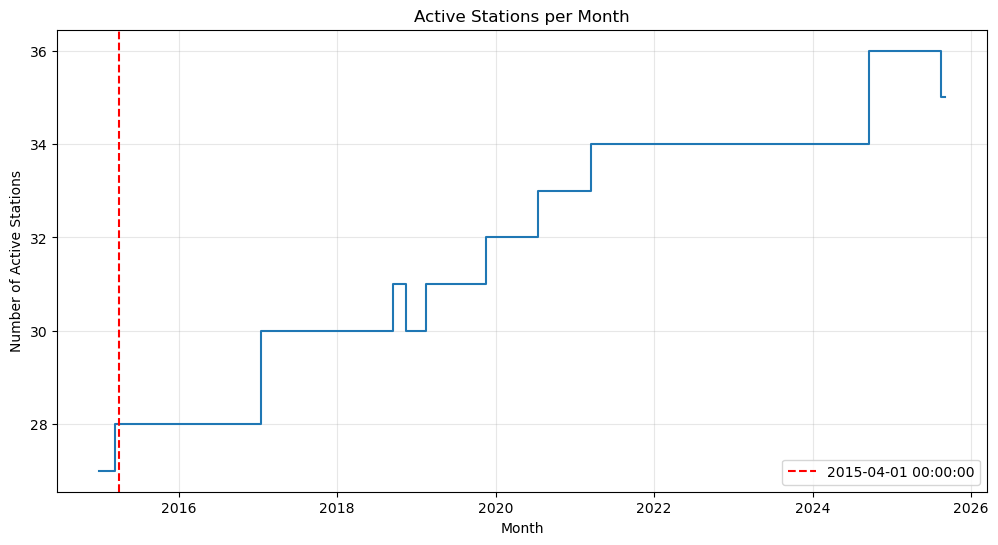

In [9]:
# Build monthly range from earliest start to latest end

all_months = pd.date_range(
    df_summary["Start Date"].min().to_period("M").to_timestamp(),
    df_summary["Final Date"].max().to_period("M").to_timestamp(),
    freq = "MS" # Month Start
)

# Count active stations per month

active_counts = []

for month in all_months:
    ##
    count = ((df_summary["Start Date"] <= month) &
             (df_summary["Final Date"] >= month)).sum()
    
    active_counts.append(count)

# Build active-count data-frame

df_active_monthly = pd.DataFrame({
    "Month" : all_months,
    "Active" : active_counts
})

# Make line-plot

plt.figure(figsize = (12, 6))

plt.plot(df_active_monthly["Month"],
         df_active_monthly["Active"], drawstyle = "steps-mid")

plt.xlabel("Month")

plt.ylabel("Number of Active Stations")

plt.title("Active Stations per Month")

plt.grid(True, alpha = 0.3)

# Add horizontal line at 2015

start_date = "2015-04-01 00:00:00"

plt.axvline(pd.Timestamp(start_date), color = "red",
            linestyle = "--", label = start_date)

plt.gca().yaxis.set_major_locator(mticker.MultipleLocator(2))

plt.legend()

plt.show()

* Now, we set the initial and final time-stamps along the period of interest and update the lists with the active stations:

In [10]:
# Set beginning / ending time and compute delta

set_beg = pd.Timestamp("2015-04-01 00:00:00")
set_end = pd.Timestamp("2025-04-01 00:00:00")

delta = pd.to_datetime(set_end) - pd.to_datetime(set_beg) 

# Convert delta to integer years + remainder days

years = delta.days // 365
days  = delta.days %  365

num_meas = int(delta.total_seconds() / 10)

# Filter stations active after in the time interval

run_stations = df_summary[
    (df_summary["Start Date"] <= set_beg) &  # started before or during interval
    (df_summary["Final Date"] >= set_end)    # ended after or during interval
]["Station"].tolist()

# Make list of active stations and update FLU/PLU subsets

active_stations = [st for st in run_stations if st in stations]

FLU_subset = [st for st in FLU_subset if st in active_stations]
PLU_subset = [st for st in PLU_subset if st in active_stations]

# Print results

print(f" > Period: {set_beg.date()} to {set_end.date()}", end = " --> ")

print(f"{years} years & {days} days ({num_meas} measurements);\n")

print(f" > Number of reasonable stations active within the period: {len(active_stations)}\n")

print(f" > Updated number of FLU stations: {len(FLU_subset)}")
print(f" > Updated number of PLU stations: {len(PLU_subset)}")

print("\n > FLU stations (updated):\n")

print("\n".join(textwrap.wrap(", ".join(map(str, FLU_subset)), width = 28)))

print("\n > PLU stations (updated):\n")

print("\n".join(textwrap.wrap(", ".join(map(str, PLU_subset)), width = 28)))

print(f"\n > Inactive stations:\n"); cnt = 0

for st in stations:
    ##
    if st not in active_stations: print(st, end = " "); cnt += 1

print(f"(total count = {cnt})")

 > Period: 2015-04-01 to 2025-04-01 --> 10 years & 3 days (31561920 measurements);

 > Number of reasonable stations active within the period: 25

 > Updated number of FLU stations: 17
 > Updated number of PLU stations: 23

 > FLU stations (updated):

143, 275, 279, 280, 283,
413, 563, 629, 1000370,
1000390, 1000410, 1000430,
1000490, 1000510, 1000580,
1000610, 1000839

 > PLU stations (updated):

143, 275, 279, 280, 283,
413, 511, 563, 629, 1000350,
1000370, 1000390, 1000400,
1000410, 1000420, 1000430,
1000490, 1000500, 1000510,
1000550, 1000837, 1000839,
1000867

 > Inactive stations:

836 1000958 1000959 1000132 1000133 1000780 (total count = 6)


* Create collection of data-frames with all data:

In [11]:
dataFrm = {} # dictionary to store filtered data-frames

#----------------------------------------
# Make first data-frame of the collection

st = active_stations[0] # first station

dataFrm[st] = dfs[st][(dfs[st][col_time] >= set_beg) & 
                      (dfs[st][col_time] <= set_end)]

nrows_prev = dataFrm[st].shape[0] 

#------------------------
# Proceed with all others

err = 0 # error counter (mismatch detection)

for st in active_stations[1:]:
    ##   
    dataFrm[st] = dfs[st][(dfs[st][col_time] >= set_beg) &
                          (dfs[st][col_time] <= set_end)]

    nrows = dataFrm[st].shape[0] 

    if (nrows != nrows_prev): err += 1 

if (err > 0):
    ##
    print("Detected mismatch in time-stamp series!")
else:
    print(f"All {len(active_stations)} data-frames match!")

All 25 data-frames match!


* Analysis of missing data in the collection 2015-2025:

,station,missing FLU (%),missing PLU (%)
0,1000580,2.77226,NaN
1,1000610,1.239086,NaN
2,1000500,NaN,0.187441
3,1000837,NaN,0.042963
4,1000350,NaN,1.983526
5,1000867,NaN,0.043723
6,511,NaN,0.034599
7,1000839,1.00412,0.537229
8,1000550,NaN,1.983716
9,1000510,1.495914,0.205881


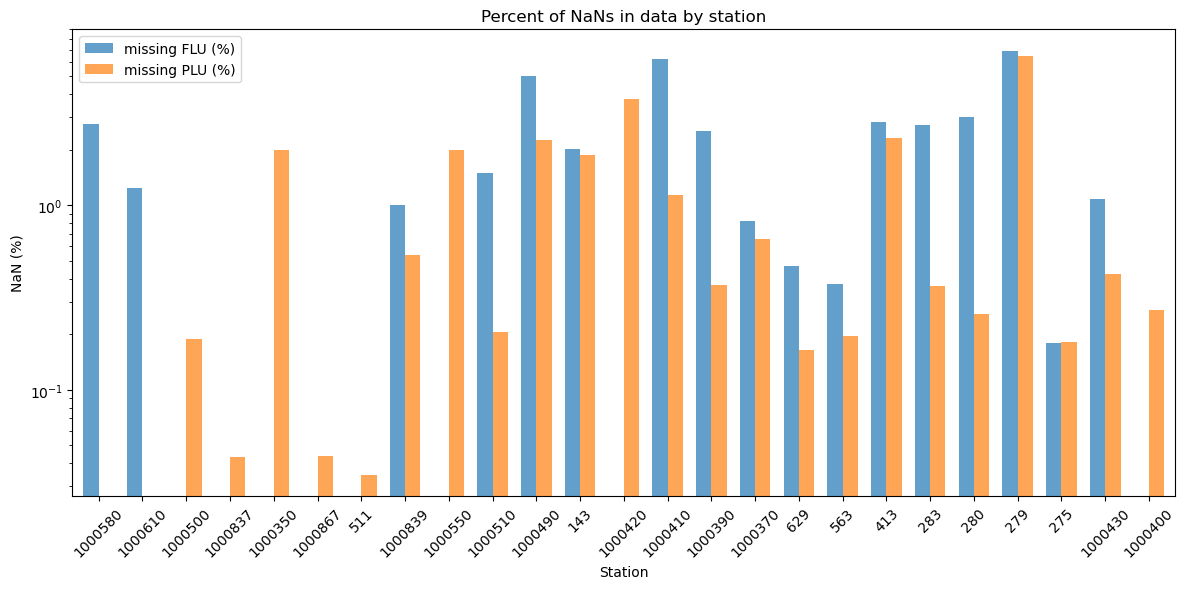

In [12]:
results = [] # collect results in a list of dicts

for st in active_stations:
    ##
    # Compute % missing per column

    if st in FLU_subset: 
        ##
        missing_FLU = dataFrm[st][colF].isna().mean() * 100
    else:
        missing_FLU = "NaN"

    if st in PLU_subset: 
        ##
        missing_PLU = dataFrm[st][colP].isna().mean() * 100
    else:
        missing_PLU = "NaN"

    results.append({"station": st,
                    "missing FLU (%)": missing_FLU,
                    "missing PLU (%)": missing_PLU})

# Convert to a dataframe and save

report_NaNs = pd.DataFrame(results)

display(report_NaNs)

# Ensure numeric (keep as floats)

report_NaNs["missing FLU (%)"] = pd.to_numeric(report_NaNs["missing FLU (%)"], errors = "coerce")
report_NaNs["missing PLU (%)"] = pd.to_numeric(report_NaNs["missing PLU (%)"], errors = "coerce")

# Plot (floats are fine here)

plot_df = report_NaNs.set_index("station")[["missing FLU (%)", "missing PLU (%)"]]

ax = plot_df.plot(kind = "bar", stacked = False,
                  alpha = 0.7, figsize = (12,6), width = 0.7)

ax.set_xlabel("Station")
ax.set_ylabel("NaN (%)")

ax.set_yscale("log")

ax.set_title("Percent of NaNs in data by station")

plt.xticks(rotation = 45)

plt.tight_layout()

plt.show()

# Save with formatted numbers (separately)

df_to_save = report_NaNs.copy()

df_to_save["missing FLU (%)"] = df_to_save["missing FLU (%)"].map(lambda x: f"{x:6.4f}" if pd.notna(x) else "")
df_to_save["missing PLU (%)"] = df_to_save["missing PLU (%)"].map(lambda x: f"{x:6.4f}" if pd.notna(x) else "")

df_to_save.to_csv("Missing_Report_2015_2025.csv", index = False)

<div style="max-width: 600px; text-align: justify;">

* Now, we analyze the gaps in stage (FLU) data and summarize in a table:

**Note:** station 413 is special among the other since it is the nearest to the TWR outlet, although it has only 2.8% (2.3%) of missing stage (rainfall) data, the table below shows that it has a long gap of ~49 days from 2023-11-16 23:40:00 to 2024-01-05 15:20:00, which represents 1.3% of the missing data;

</div>

In [13]:
col = colF # target column to analyze

longest_segments = []

for st in FLU_subset:
    ##
    df = dataFrm[st]

    is_na = df[col].isna().astype(int)

    count = 0

    max_len = 0

    start_idx = None
    max_start = None
    max_final = None

    for i, val in enumerate(is_na):
        ##
        if val == 1:
            ##
            if count == 0:
                ##
                start_idx = i # start of new NaN block

            count += 1
        else:
            if count > max_len:
                ##
                max_len = count

                max_start = start_idx
                max_final = i - 1                
                
            count = 0; start_idx = None

    # Check if last segment is the longest

    if count > max_len:
        ##
        max_len = count

        max_start = start_idx
        max_final = len(is_na) - 1        
        

    if max_len > 0:
        ##
        time1 = df[col_time].iloc[max_start]
        time2 = df[col_time].iloc[max_final]

        longest_segments.append({
            "station": st,
            "gap"    : max_len,
            "start"  : time1,
            "end"    : time2
        })

# Convert to DataFrame

longest_df = pd.DataFrame(longest_segments)

longest_df["days"] = (longest_df["gap"] * 10 / (60 * 24)).astype(int)

cols = ["station", "gap", "days", "start", "end"]

longest_df = longest_df[cols]

longest_df = longest_df.sort_values("gap", ascending = False)

longest_df.to_csv("NaNLen_Report_FLU_2015_2025.csv", index = False)

display(longest_df)

,station,gap,days,start,end
2,279,21864,151,2021-09-04 22:20:00,2022-02-03 18:10:00
12,1000490,18619,129,2024-11-22 17:00:00,2025-04-01 00:00:00
0,143,8788,61,2021-09-30 16:50:00,2021-11-30 17:20:00
4,283,7857,54,2021-05-27 03:00:00,2021-07-20 16:20:00
5,413,7151,49,2023-11-16 23:40:00,2024-01-05 15:20:00
14,1000580,4886,33,2024-09-24 18:30:00,2024-10-28 16:40:00
9,1000390,4885,33,2024-09-24 18:30:00,2024-10-28 16:30:00
10,1000410,1854,12,2020-02-05 19:30:00,2020-02-18 16:20:00
15,1000610,1581,10,2024-09-26 15:10:00,2024-10-07 14:30:00
11,1000430,1580,10,2024-09-26 15:10:00,2024-10-07 14:20:00


<div style="max-width: 900px; text-align: justify;">

#### **Preparing the dataset for the ML4FF framework:**

**Overview:**

For the ML approach based on gauge stations, accumulated rainfall data were extracted from the 23 rain gauge (PLU) time series. Combined with stage measurements from Station 413 (the gauge closest to the watershed outlet), this corresponds to a set of 24 synchronized time series. To enable direct comparison with the approaches based on accumulated rainfall derived from radar fields, all 24 series were aligned to a common timeline defined by the overlapping intervals between the stage and radar data. Hence, the first step below consists in creating a list of time-stamps *nan_times* for which stage and/or radar data are/is not available. This list also includes two periods in 2017 where anomalies were detected (e.g.: sudden unphysical peaks and plateaus on stage data with no rainfall signal from all 23 rain gauges). The next step focuses on the stage time series from station 413. In order to apply our custom filtering function *filtfilt_sliding*, all missing data within the raw time-series in "dataFrm[413][[col_time, colF]]" were filled with numerical data. The procedure used is a forward-fill using a rolling mean computed with the last 5 valid measurements, and for missing rainfall data a simple "fill with zeroes" was applied. With the "continuous" (10-min. grid) series in hands, it was then processed to remove outliers and smooth non-physical fluctuations caused by sensor malfunction and/or environmental disturbances, technical details of the process are explained below. Lastly, our the machine-learning ready dataset is obtained after all data associated with the time-stamps in *nan_times* are removed from the 24 synchronized time series.

**Stage filtering details:** 

Outlier detection was performed using a *Hampel* identifier, which flags measurements exceeding a median-based deviation threshold within a sliding window and replaces them with the local median. Subsequently, a custom filtering procedure was applied to suppress high-frequency noise. A low-pass finite impulse response filter was used, with the cutoff frequency set to 20% of the *Nyquist* frequency, employing a *Hann* temporal window and achieving zero-phase distortion by means of a forward-reverse scheme, which cancels the delays typically introduced by causal filters and preserves the timing of hydrograph peaks. To mitigate boundary transients and ringing artifacts, the signal was processed with a sliding window of size 500 with 10% reflection padding. The filtering procedure was applied twice: first to identify remaining outliers relative to the locally smoothed signal, and then again -- after removing these outliers -- to obtain the final time series.

</div>

* Create *nan_times* list:

In [14]:
# Set custom ranges to assign NaNs (anomalies, repeating values)

start1 = pd.to_datetime("2017-03-20 20:00:00")
final1 = pd.to_datetime("2017-03-30 16:00:00")

start2 = pd.to_datetime("2017-05-08 00:00:00")
final2 = pd.to_datetime("2017-05-18 00:00:00")

# Read radar NaN time-stamps

inputFile = "Aux_Files/NaN_times_radar_2015-2025.csv"

radar_nan_list = pd.read_csv(inputFile, parse_dates = [0])

radar_nan_times = radar_nan_list.iloc[:, 0].tolist()

# Step 1: Copy relevant columns for st = 413

dfWork = dataFrm[413][[col_time, colF]].copy()

# Step 2: Find all timestamps where colF is NaN

dfNA = dfWork.loc[dfWork[colF].isna(), col_time]

dfNA.to_csv("FLU413_NaN_times.csv", index = False)

nan_times = dfNA.tolist()

# Build new timestamps to add

extra_nan_times = dfWork[
    ((dfWork[col_time] >= start1) & (dfWork[col_time] <= final1)) |
    ((dfWork[col_time] >= start2) & (dfWork[col_time] <= final2))
][col_time].tolist()

# Add to existing list

nan_times.extend(extra_nan_times)
nan_times.extend(radar_nan_times)

nan_times = set(nan_times)

print(f"Timestamps with NaN in {colF}:", len(nan_times))

Timestamps with NaN in FLUm: 395345


* Apply Hampel identifier and custom filtering function on the stage data:

In [15]:
# Stage signal filtering function with sliding-window
# and zero-phase FIR filter using filtfilt and with
# optional outlier detection and replacement:

def filtfilt_sliding(
        dataFrm: pd.DataFrame,
        col_time: str,
        col_lvls: str,
        out_cols: list,
        cutoff_ratio: float = 0.25,
        rolloff_fac: float = 0.10,
        win_size: int = 500,
        pad_size: int = 50,
        fir_order: int = 33,
        threshold: float = 1.0,
        remove_outliers: bool = False
    ) -> pd.DataFrame:
    """
    Parameters
    ----------
    dataFrm : pd.DataFrame
        Input dataframe.
    col_time : str
        Column name for time (timestamps or numeric).
    col_lvls : str
        Column name for signal values.
    out_cols : list
        Output column names [time, original, filtered].
    cutoff_ratio : float
        Fraction of Nyquist frequency for cutoff.
    rolloff_fac : float
        Not used for FIR, kept for compatibility.
    win_size : int
        Sliding window size.
    pad_size : int
        Number of points to pad at each end (signal extension).
    fir_order : int
        Number of FIR taps (filter length).
    remove_outliers : bool
        Whether to detect and replace outliers before filtering.
    threshold : float
        Threshold for outlier detection.

    Returns
    -------
    pd.DataFrame
        DataFrame with columns [time, original, filtered].
    """

    # --- TIME AND SIGNAL VECTORS ---

    time_vec = dataFrm[col_time].reset_index(drop = True)
    lvls_vec = dataFrm[col_lvls].reset_index(drop = True).values

    # --- SAMPLING INTERVAL ---

    dt0 = time_vec.iloc[1] - time_vec.iloc[0]

    dt  = dt0.total_seconds() / 60.0 if isinstance(dt0, pd.Timedelta) else float(dt0)

    fs = 1.0 / dt

    N  = len(lvls_vec)

    # --- FILTER SPECS ---

    f_nyq = fs / 2

    cutoff_hz = cutoff_ratio * f_nyq

    # --- FIR FILTER COEFFICIENTS ---

    if fir_order % 2 == 0: fir_order += 1

    b = signal.firwin(
        numtaps   = fir_order,
        cutoff    = cutoff_hz,
        fs        = fs,
        window    = "hann",
        pass_zero = "lowpass"
    )

    # --- HELPER FUNCTION ---
    
    def run_filter(signal_vec):        
        """
           Apply sliding-window
           filtfilt on input vector:
        """
        segments = []

        for beg in range(0, N, win_size):
            ##
            end = min(beg + win_size, N)

            lvls_win = signal_vec[beg:end]
            time_win = time_vec.iloc[beg:end]

            pad_left  = min(pad_size, beg)
            pad_right = min(pad_size, N - end)

            lvls_pad = np.pad(lvls_win, (pad_left, pad_right), mode = "reflect")

            filtered_pad = signal.filtfilt(b, [1.0], lvls_pad, method = "gust")

            core_beg = pad_left
            core_end = pad_left + len(lvls_win)

            filtered_core = filtered_pad[core_beg:core_end]

            segments.append(pd.DataFrame({
                out_cols[0]: time_win.values,
                out_cols[1]: lvls_win,
                out_cols[2]: filtered_core
            }))            

        return pd.concat(segments, ignore_index = True)

    # --- STEP 1: INITIAL FILTERING ---

    fcdataFrm = run_filter(lvls_vec)

    # --- STEP 2: OUTLIER HANDLING (OPTIONAL) ---

    if remove_outliers:
        ##
        diff_series = (fcdataFrm[out_cols[1]] - fcdataFrm[out_cols[2]]).abs()

        diff_series = diff_series.where(diff_series > threshold, 0)

        ## Outlier indices
        ##
        outlier_idx = sorted(diff_series[diff_series > 0].index)

        outlier_set = set(outlier_idx)

        lvls_clean  = lvls_vec.copy()

        ## Replace each outlier
        ##
        for idx in outlier_idx:
            ##
            left  = idx - 1
            right = idx + 1

            while left >= 0 and left in outlier_set: left -= 1

            while right < N and right in outlier_set: right += 1

            if left >= 0 and right < N:
                lvls_clean[idx] = (lvls_clean[left] + lvls_clean[right]) / 2.0
            elif left >= 0:
                lvls_clean[idx] = lvls_clean[left]
            elif right < N:
                lvls_clean[idx] = lvls_clean[right]

        ## Re-run filtering with cleaned signal
        ##
        fcdataFrm = run_filter(lvls_clean)

    return fcdataFrm

In [16]:
# Set cutoff, rolloff and 
# filter order parameters:

cf_val = 0.20
rf_val = 0.40
fr_ord = 13

# Set processed data-frame output format 
# (FLU_RAW is the unfiltered time-series):

out_list = [col_time, "FLU_RAW", colF]

# Initialize the full reference data-frame:

full_index = pd.date_range(set_beg, set_end, freq = "10min")

dataML4FF = pd.DataFrame({col_time: full_index})

# ---------------------
# Process all PLU data:

cnt = 0

sz = len(PLU_subset)

print(" Processing rainfall data...", end = " ")

for st in active_stations:
    ##    
    if st in PLU_subset:
        ##
        dfWork = dataFrm[st][[col_time, colP]].copy()

        # Forward-fill values (zeroes)     

        dfWork[colP] = dfWork[colP].fillna(0)

        dfWork = dfWork.rename(columns = {colP: f"{colP}_{st}"})

        # Merge with dataML4FF

        dataML4FF = dataML4FF.merge(dfWork, on = col_time , how = "left")

print("Done!\n")

# -----------------------------
# Process station 413 FLU data:

st = 413

dfWork = dataFrm[st][[col_time, colF]].copy()

# Forward-fill values (rolling window):

print(" Processing stage data...", end = " ")

rolling_mean = dfWork[colF].rolling(window = 5, min_periods = 1).mean()

dfWork[colF] = dfWork[colF].fillna(rolling_mean).ffill()    

# Apply Hampel filtering (remove outliers):

lvl_series = hampel(dfWork[colF], window_size = 10, n_sigma = 2.5)

dfWork[colF] = lvl_series.filtered_data.values

# Apply FFT two-pass filtering (smooth & remove outliers again):

dfOut = filtfilt_sliding(dfWork, col_time, colF, out_list, 
                        cutoff_ratio = cf_val, rolloff_fac = rf_val, 
                        win_size = 500, pad_size = 50, fir_order = fr_ord,
                        threshold = 1.0, remove_outliers = True)
print("Done!\n")

# ------------------------------------------          
# Prepare dfWork with renamed column & merge
# Merge with reference data-frame (dataML4FF):
        
dfWork = dfOut[[col_time, colF]].copy()

dfWork = dfWork.rename(columns = {colF: f"{colF}_{st}"})

dataML4FF = dataML4FF.merge(dfWork, on = col_time , how = "left")

dataML4FF_Full = dataML4FF.copy() #<--- Copy with the full series;

# ------------------------------------------------------------------------
# Now, dataML4FF contains all stations with columns aligned to full_index:
#
# Before recording, we remove the all NaN time-stamps where FLU and/or 
# radar data is unavailable, which were filled using a rolling-mean
# method in order to apply the Hample + FFT(2-pass) filtering ...

print(" Removing original NaN intervals...", end = " ")

dataML4FF = dataML4FF[~dataML4FF[col_time].isin(nan_times)]

print("Done!")

dataML4FF.to_csv("ML4FF_Datasets/Data_Tamanduatei_Smooth_FLU413_and_PLU_2015_2025.csv", index = False)

 Processing rainfall data... Done!

 Processing stage data... Done!

 Removing original NaN intervals... Done!


* Lastly, let us use a fine-tuned plotting function given below to verify the stage filtering:

In [17]:
# Here we set plotting configurations for
# libraries Matplotlib and Seaborn:

sns.set_style("whitegrid")

plt.rcParams.update({
    "figure.dpi": 120,
    "font.family": "Sans",
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "axes.linewidth": 1.0,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "axes.edgecolor": "black",
    "axes.facecolor": "white",
})

In [18]:
# The function below produces high-quality time-series
# plots for comparison of stage data together with
# rainfall data from rain gauges or radar fields:

def plot_series_comparison(
    dfrm1: pd.DataFrame,
    dfrm2: pd.DataFrame = None,
    dfrm3: pd.DataFrame = None,
    dfRef: pd.DataFrame = None,
    time_col: str = "time",
    pred_col: str = "pred",
    true_col: str = "true",
    rain_col: str = None,
    lvls_col: str = None,
    fill_frm: str = None,
    plot_range = None,
    fname: str = None,
    title: str = None,
    labelLst: list = None,
    colorLst: list = None,
    tstamp1: pd.Timestamp = None, 
    tstamp2: pd.Timestamp = None, 
    with_radar: bool = False,     
    zoom_pmode: bool = False,
    hide_NSE_table: bool = False,
    hide_plot: bool = False,
    hide_lbox: bool = False
) -> tuple:
    """
    Plot comparison between holdout data and
    model predictions for different lead times;

    Optionally compute NSE over the period
    defined by tval1 & tval2 (if provided);

    Returns: (update) """

    # =====================
    # Setup figure and axis

    color_gauge = "#3B6697"

    color_radar = "#A02B93"

    if zoom_pmode is False:
        ## 
        fig, ax = plt.subplots(figsize=(15, 4)); lwd = 1.5 #( 0.8 ()
    else:
        fig, ax = plt.subplots(figsize=(8.5, 4)); lwd = 1.2

    if with_radar:
        ##
        color_rain = color_radar
    else:
        color_rain = color_gauge

    if labelLst is None:
        ##
        labelLst = ["Observed stage", "LD 10 min", 
                    "LD 60 min", "LD 120 min", "LD 240 min"]
        
    if colorLst is None:
        ##
        colorLst = ["#FF7C24", "#12AD67", "#CC2418", "#C20AA3"]          

    # =======================================
    # Plot holdout (true data) as filled area

    if fill_frm == "dfrm1":
        ##
        ax.fill_between(dfrm1[time_col], dfrm1[true_col],
                        color="#696969", alpha=0.2)
    
    if (lvls_col is not None) and (dfRef is not None):
        ##
        ax.plot(dfRef[time_col], dfRef[lvls_col],
                color="#444444", lw=lwd, label=labelLst[0])  
        
        if fill_frm == "dfRef":
            ##
            ax.fill_between(dfRef[time_col], dfRef[lvls_col],
                    color="#696969", alpha=0.2)
    else:
        ax.plot(dfrm1[time_col], dfrm1[true_col],
                color="#444444", lw=lwd, label=labelLst[0])  
        
    # ======================
    # Plot model predictions 

    dfs = [dfrm1, dfrm2, dfrm3]

    for df, color, label in zip(dfs, colorLst, labelLst[1:]):
        ##
        if df is not None:
            ##
            ax.plot(df[time_col], df[pred_col],
                    label=label, color=color, lw=lwd)

    # =========================
    # Labels, title, and legend

    title = title or ""

    ax.set_title(title, loc="left", pad=10, fontsize=12)

    ax.set_xlabel("Time instant", fontsize=12)
    
    ax.set_ylabel("Stage (m)", fontsize=12)

    #ax.legend(frameon=True, fancybox=True, framealpha=1.0,
    #          shadow=False, loc="upper left")
    
    if not hide_lbox:
        ##
        ax.legend(frameon=True, fancybox=True, framealpha=1.0, shadow=False,
                  loc='upper center', bbox_to_anchor=(0.5, -0.3),
                  ncol=len(ax.lines))

    # =========================
    # Grid, ticks, and rotation

    ax.grid(True, linestyle="--", alpha=0.4, lw = 0.6)

    ax.tick_params(direction="inout", length=4, width=1)

    locator = mdates.AutoDateLocator()

    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))

    plt.setp(ax.get_xticklabels(), rotation=0, ha="right")

    plt.gca().yaxis.set_major_locator(plt.MultipleLocator(1))

    # plt.gca().yaxis.set_major_locator(plt.MaxNLocator(nbins = 3))

    # ============================
    # Add box around plot (spines)

    for spine in ax.spines.values():
        ##
        spine.set_visible(True)
        spine.set_linewidth(0.8)

    # ===================
    # Limit x and y range

    if (lvls_col is not None) and (dfRef is not None):
        ##
        data_y = dfRef[lvls_col]

        mask = ( (dfRef[time_col] >= plot_range[0]) & 
                 (dfRef[time_col] <= plot_range[1]) )
    else:
        data_y = dfrm1[true_col]

        mask = ( (dfrm1[time_col] >= plot_range[0]) & 
                 (dfrm1[time_col] <= plot_range[1]) )

    if plot_range is not None:
        ##
        ax.set_xlim(plot_range)

        if mask.any():
            ##
            if (lvls_col is not None) and (dfRef is not None):
                ##  
                data_y = dfRef.loc[mask, lvls_col]
            else:
                data_y = dfrm1.loc[mask, true_col]

    y_min, y_max = data_y.min(), data_y.max()

    margin = 0.01 * (y_max - y_min) # 0.075

    ax.set_ylim(y_min - margin, y_max + 5.0 * margin)

    # ================================
    # Add reference line (alert level)

    alert_lvl = 722.779 #( river level for alert )

    hline = ax.axhline(alert_lvl, color="black", lw=lwd, ls="--")

    hline.set_dashes([3, 4])

    # ==================
    # Add vertical lines

    for tval in [tstamp1, tstamp2]:
        ##    
        if tval is not None:
            ##
            tval_dt = pd.to_datetime(tval)
            
            vline = ax.axvline(tval_dt, color=color_rain, lw=lwd, ls="--")

            vline.set_dashes([3, 4])

    # ===========================================
    # Compute NSE if tval1 and tval2 are provided

    nse_values = None

    if tstamp1 is not None and tstamp2 is not None:
        ##
        t1 = pd.to_datetime(tstamp1)
        t2 = pd.to_datetime(tstamp2)

        nse_list = []

        for df in [d for d in dfs if d is not None]:
            ##
            sub_df = df[(df[time_col] >= t1) & (df[time_col] <= t2)]

            if len(sub_df) < 2 or sub_df[true_col].nunique() == 1:
                ##
                nse_list.append(np.nan); continue
            
            obs = sub_df[true_col].to_numpy()
            sim = sub_df[pred_col].to_numpy()

            nse = 1 - np.sum((obs - sim)**2) / np.sum((obs - np.mean(obs))**2)

            nse_list.append(nse)

        nse_values = tuple(nse_list)
    
        # Add inset text box with NSE

        if hide_NSE_table is not True:
            ##
            textstr = "\n".join([
                f"NSE({lbl.split(': ')[1]}) = {val:.3f}"
                for lbl, val in zip(labelLst, nse_values)
            ])
            
            props = dict(boxstyle='round', facecolor='white',
                        alpha=0.8, edgecolor='red')

            anchored_text = AnchoredText(textstr, loc="upper right",
                            prop=dict(size=8), frameon=True)

            anchored_text.patch.set_boxstyle(props["boxstyle"])

            anchored_text.patch.set_facecolor(props["facecolor"])

            anchored_text.patch.set_alpha(props["alpha"])

            anchored_text.patch.set_edgecolor(props["edgecolor"])

            anchored_text.set_bbox_to_anchor((1.0, 1.0), transform=ax.transAxes)
            
            anchored_text.pad = 0.05
            
            ax.add_artist(anchored_text)
    
    # =================================
    # Add PLU or radar data if provided

    if (rain_col is not None) and (dfRef is not None):
        ##
        ax.set_zorder(1)

        ax_plu = ax.twinx()

        ax_plu.set_zorder(0)        
        
        ax.patch.set_visible(False)

        ax_plu.set_ylabel("Rainfall (mm)", color=color_rain)       

        ax_plu.fill_between(dfRef[time_col], dfRef[rain_col],
                            step="post", color=color_rain, alpha=0.2)
        
        ax_plu.plot(dfRef[time_col], dfRef[rain_col], lw=0.4,
                    color=color_rain, drawstyle="steps-post")

        ax_plu.tick_params(axis="y", labelcolor=color_rain)
        
        ax_plu.grid(True, linestyle="dotted",
                    alpha=0.3, lw=0.6, color=color_rain)
        
        ax_plu.invert_yaxis() #( mirroring )

        if zoom_pmode: 
            ##
            max_val_2 = 10
        else:
            max_val_2 = dfRef[rain_col].max()

        if pd.isna(max_val_2) or max_val_2 == 0:
            ##
            max_val_2 = 1.0 #( or any small positive value )

        ax_plu.set_ylim(max_val_2 * 1.1, 0)

        if zoom_pmode:
            ##
            plt.gca().yaxis.set_major_locator(plt.MultipleLocator(2))
        else:
            plt.gca().yaxis.set_major_locator(plt.MultipleLocator(5))

        dummy1 = Line2D([], [], color=color_gauge, lw=lwd, label="Rain gauge")
        dummy2 = Line2D([], [], color=color_radar, lw=lwd, label="Radar")

        lines1, labels1 = ax.get_legend_handles_labels()

        lines2, labels2 = ax_plu.get_legend_handles_labels()
                
        if not hide_lbox:
            ##
            leg = ax.legend(
                handles=lines1 + lines2 + [dummy1, dummy2] ,
                loc='upper center', bbox_to_anchor=(0.5, -0.3),
                ncol=6, frameon=True, fancybox=True,
                framealpha=1.0, handlelength=1.0,
                handleheight=1.0, handletextpad=0.4,
                fontsize=12)

            for h in leg.get_lines(): h.set_linewidth(2.0)

    # =======================
    # Final layout and output    

    plt.tight_layout()

    if fname: plt.savefig(fname, bbox_inches="tight")

    if not hide_plot: plt.show()

    plt.close(fig)

    return nse_values

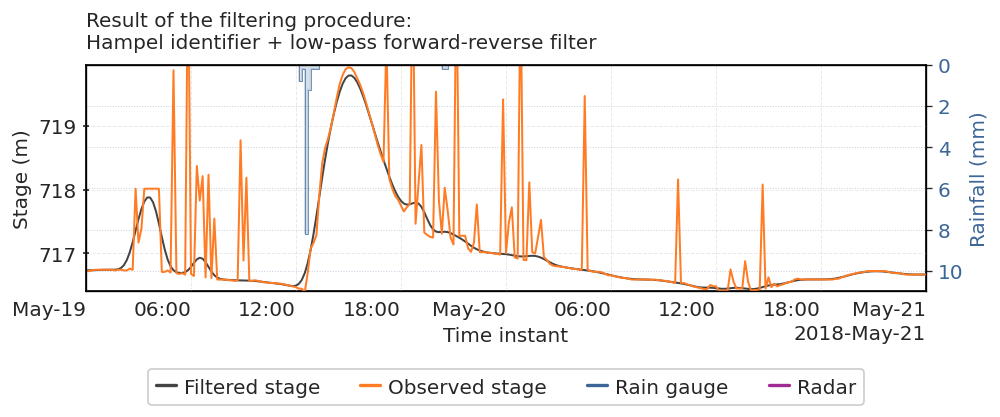

In [19]:
# We choose a time-range where stage measurements 
# increase due to rainfall and also display spikes
# caused by sensor malfunction during the event:

t_left  = "2018-05-19"
t_right = "2018-05-21"

dftest = dataFrm[413].copy()

dfRaw = dftest[(dftest[col_time] >= t_left) & \
               (dftest[col_time] <= t_right)].copy()

# With the data-frame for the selected period, we
# apply the forward-fill procedure with rolling-mean:

rolling_mean = dfRaw[colF].rolling(window = 5, min_periods = 1).mean()

dfRaw[colF] = dfRaw[colF].fillna(rolling_mean).ffill()

# Now, we apply the Hampel identifier to remove outliers:

lvl_series = hampel(dfRaw[colF], window_size = 10, n_sigma = 2.5)

dfWork = dfRaw.copy()

dfWork[colF] = lvl_series.filtered_data.values

# Next, the FFT-based low-pass filter is applied:

out_list = [col_time, "FLU_RAW", "FLU_NEW"]

dfOut = filtfilt_sliding(dfWork, col_time, colF, out_list, 
                          cutoff_ratio = cf_val, rolloff_fac = rf_val, 
                          win_size = 500, pad_size = 50, fir_order = fr_ord,
                          threshold = 1.0, remove_outliers = True)

# The data-frame above contains two stage data columns, 
# the 1st (FLU_RAW) results from the Hampel filter,
# the 2dn (FLU_NEW) results from the subsequent 
# application of the function filtfilt_sliding;
#
# We want to compare the final stage data with
# the original values, hence we replace in (*)
# and then plot using plot_series_comparison:

dfOut["FLU_RAW"] = dfRaw[colF].values #( * )

title = "Result of the filtering procedure:"

subtitle = "Hampel identifier + low-pass forward-reverse filter"

plotName = f"{title}\n{subtitle}"

time_range = [ pd.Timestamp(t_left) , pd.Timestamp(t_right) ]

plot_series_comparison(
    dfrm1 = dfOut,
    dfRef = dataML4FF,
    time_col = col_time,
    pred_col = "FLU_RAW",
    true_col = "FLU_NEW",
    rain_col = "PLUmm_413",
    labelLst = [ "Filtered stage", "Observed stage" ],
    plot_range = time_range, title = plotName, zoom_pmode = True)

<div style="max-width: 900px; text-align: justify;">

#### **Creating the datasets with 24 input feature vectors for the ML4FF framework:**

The 24 time series within *dataML4FF* were used as input feature vectors forming the datasets to train, validate, and test the LinearSVR and XGBRegressor models, with the target variable being the stage at a specified forecast lead time. This target variable must be included within the datasets for the ML4FF framework, below this is done by adding another column with the stage time series shifted by the lead time (negative shift applied to copied stage column). The results of the framework is a trained and optimized model (via nested cross-validation and hyper-parameter tuning) whose output corresponds to the predicted stage at the lead time T = 10, 60, or 120 min.

</div>

In [20]:
# -----------------
# Set column names:

colF = "FLUm"  # Data column names
colP = "PLUmm" # with FLU/PLU values

flu413 = colF + "_413" # Outlet FLU/PLU
plu413 = colP + "_413" # column names

col_time = "time-stamp" # Data column name for
col_year = "year"       # time-stamps and year

# -----------------------------------
# Prepare working data-frames with
# times within the period of interest:

df = dataML4FF.copy()

df[col_year] = df[col_time].dt.year

year1 = 2015
year2 = 2025

period = f"{year1}-{year2}"

df = df.loc[(df[col_year] >= year1) & 
            (df[col_year] <= year2)].copy()

# --------------------------------
# Build new data-sets by shifting:

target = flu413

tag = "radar_compatible"

# Shift mapping: minutes --> negative steps

shifts = {
    10:  [ -1],
    60:  [ -6],
    120: [-12],
    240: [-24],
}

# Loop over steps (lead-times):

for minutes, (step) in shifts.items():
    ##
    df_shifted = df.drop(columns = [col_year]).copy()

    cols_to_shift = df_shifted.columns[1:-1]

    cols = [c for c in df_shifted.columns if c != target] + [target]

    df_shifted = df_shifted[cols]

    df_shifted[f"{target}_out_{minutes}min"] = df_shifted[target].shift(step)

    df_shifted = df_shifted.dropna().reset_index(drop = True)

    df_shifted.to_csv(f"ML4FF_Datasets/stage413_and_rain-gauges_{period}_{tag}-{minutes}min.csv", index = False)

<div style="max-width: 900px; text-align: justify;">

### **Part 2**

---

### **Flash-flood modeling with the ML4FF framework:<br>a guide for producing stage forecasting models and a<br>step-by-step analysis of their performance and predictions**

</div>

<div style="max-width: 900px; text-align: justify;">

#### **Analyzing output XGBRegressor models from the ML4FF framework:**

**Framework execution:**

One can run the ML4FF framework for several machine-learning models using the dataset created before by means of the Python script *Run_ML4FF_Code.py* shown on the cell below. In this code, the user can set the input datasets by specifying the source directory (DATASET_ROOT), the base-name (DATASETS), and the different lead-times (LEAD_TIMES) associated with each file previously prepared by the user. The desired models are set within a list (ALGORITHMS), then one can just run *python Run_ML4FF_Code.py* (within a the ML4FF environment) to execute the full automated pipeline that produces trained and optimized models. The execution configuration for the cross-validation procedure are set by INNER_CV, OUTER_CV and HOLDOUT_SLICE (the pseudo-random-number-generator seed is set by SEED), the provided code runs in both Linux and Windows machines, and the user can specify the number of threads for parallel computing by changing CPU_AFFINITY_QTD (this works well on Linux, but, unfortunately, in Windows the CPU-affinity must be configured in another way).

**Results analysis:**

The successful execution of the script provided produces outputs for a total of 6 models (one for each ML algorithm and lead-time): LinearSVR and XGBRegressor for lead-times 10, 60, 120 and 240 min. Here, we analise the outputs for XGBRegressor models located in the directory "ML4FF_Results/XGBReg_Output_Gauge_Rainfall", these were obtained by executing the script (with the same configurations and input files given in this guide) in a Windows machine with a 12th Gen. Intel Core i9-12900KF (3200 Mhz, 16 Cores, 24 Threads) CPU and 96 GB of RAM. We are interested in the outputs recorded in a summary file called "Summary.xlsx" created by the framework for each model. The sheet "Statistics" contains the statistics (variance, median, mean and max/min) associated with the performance metrics (NSE, KGE and RMSE) from all intermediary models generated during the first phase, which employs a nested cross-validation scheme consisting of 12/6 outer/inner folds and uses 87.5% of the data. Here, we are particularly interested in the results for the final/optimized model evaluated during the second phase, which uses only the holdout set corresponding to the unseen 12.5% of the data. In the sheet "Predictions", for the whole timeline of the holdout set, the stage measurements at times $t$ and the predictions made by the optimized model for the future stage at $t+t_{\text{\,lead-time}}$ can be found.

The step-by-step presentation and analysis of the results follows now.

</div>

In [1]:
# Here, we display the Python code used to execute
# the ML4FF framework for ML models LinearSVR and 
# XGBRegressor for lead-times 10, 60, 120 & 240 min:

from IPython.display import HTML

from pathlib import Path

code = Path("Run_ML4FF_Code.py").read_text()

HTML(f"""
<pre style="
    max-height: 450px;
    overflow: auto;
    background-color: #1e1e1e;
    color: #d4d4d4;
    padding: 14px;
    border: 1px solid #444;
    border-radius: 6px;
    font-family: Consolas, Monaco, 'Courier New', monospace;
    font-size: 13px;
    line-height: 1.4;
">
{code}
</pre>
""")

* Now we read the sheet "Statistics" and display the second phase metrics for the optimized model:

In [22]:
files_dir = "ML4FF_Results/XGBReg_Output_Gauge_Rainfall/" #<--- Outputs directory;

model_tag = "XGBReg" #<--- Model tag for plotting;

# =======================================================
# Create directory for output plots (if it doesn't exist)

plots_dir = os.path.join(files_dir, "xPlots/")

os.makedirs(plots_dir, exist_ok = True)

# =======================
# Load CSVs and read data

baseName = "stage413_and_rain-gauges"

fileName1 = files_dir + f"{baseName}-10min/Summary.xlsx"
fileName2 = files_dir + f"{baseName}-60min/Summary.xlsx"

fileName3 = files_dir + f"{baseName}-120min/Summary.xlsx"
fileName4 = files_dir + f"{baseName}-240min/Summary.xlsx"

# =================================================
# Read only "Statistics" sheet from each Excel file

def read_stat(fn):
    ##
    df = pd.read_excel(fn, sheet_name = "Statistics")

    df = df.iloc[:4, 1:] #( take first 4 metrics, skip metric name column )

    return df

dfs = [read_stat(f) for f in [fileName1, fileName2, fileName3, fileName4]]

# ==============================================
# Concatenate side-by-side and add column labels 

df_concat = pd.concat(dfs, axis = 1)

df_concat.columns = ["10 min", "60 min", "120 min", "240 min"]

# =========================================================
# Add metric names from first file and save CSV with scores

fileName0 = files_dir + "Scores.csv"

metric_names = pd.read_excel(fileName1,
               sheet_name = "Statistics").iloc[:4, 0].reset_index(drop = True)

df_concat.insert(0, "Score", metric_names)

df_concat = df_concat[df_concat["Score"] != "NSE_Norm_Holdout"]

order = [0, 2, 1] + list(range(3, len(df_concat)))

df_concat = df_concat.iloc[order].reset_index(drop = True)

df_concat.to_csv(fileName0, index = False)

print(df_concat)

          Score    10 min    60 min   120 min   240 min
0   NSE_Holdout  0.994505  0.938756  0.809393  0.515681
1   KGE_Holdout  0.989828  0.961429  0.856902  0.573000
2  RMSE_Holdout  0.079577  0.265664  0.468673  0.747108


* We can make a nice bar-plot comparing the metric for all models:

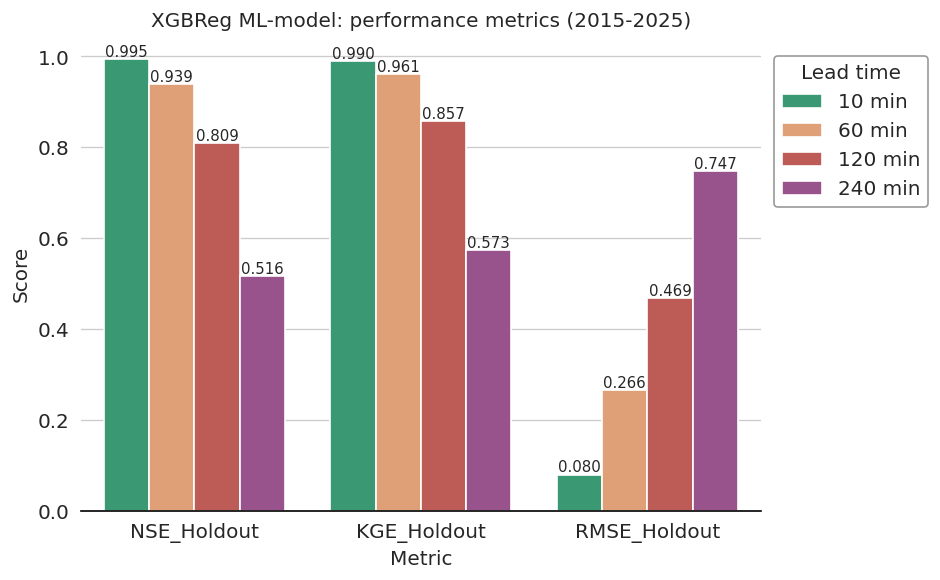

In [23]:
# ======================================================
# OKLCH palette for high perceptual contrast and harmony

cvec = ["#2AA876", "#F19C65", "#CE4D45", "#A44795"]

# ======================
# Melt table for Seaborn

data = df_concat.copy()

df_melt = data.melt(id_vars = ["Score"], 
                    var_name = "Lead_time", 
                    value_name = "Value")

# =============
# Create figure

plt.figure(figsize = (8,5))

ax = sns.barplot(data = df_melt, x = "Score", y = "Value",
                 hue = "Lead_time", palette = cvec)

# =========================
# Annotate bars with values

for p in ax.patches:
    ##
    height = p.get_height()

    if height > 0:
        ##
        ax.annotate(f"{height:.3f}",
                    (p.get_x() + p.get_width() / 2.0, height),
                    ha = 'center', va = 'bottom', fontsize = 9)

# ================
# Title and labels

plt.title(f"{model_tag} ML-model: performance metrics ({period})")

plt.xlabel("Metric", fontsize = 12)

plt.ylabel("Score", fontsize = 12)

plt.xticks(rotation = 0)

# =================
# Legend & note box

add_notes = False

plt.legend(
    title = "Lead time",
    loc = "center left",
    bbox_to_anchor = (1.005, 0.8),
    frameon = True, framealpha = 0.8,
    facecolor = "white", edgecolor = "gray"
)

if add_notes:
    ##
    note_text = (
        "Training settings:\n\n"
        "• Inner_Loop = 6  \n\n"
        "• Outer_Loop = 12 \n\n"
        "• FLU station: outlet\n\n"        
        "• Input_FLU: 01 st.  \n\n"
        "• Input_PLU: 23 sts. \n\n"
        "• Output: outlet FLU \n"
        "   for 4 lead-times;"
    )

    note = AnchoredText(note_text, loc = "upper left",
                        bbox_to_anchor = (1.005, 0.675),
                        bbox_transform = plt.gca().transAxes,
                        frameon = True, prop = {'size': 12})

    note.patch.set_boxstyle("round,pad = 0.25, rounding_size = 0.25")

    note.patch.set_facecolor("white")
    note.patch.set_edgecolor("gray")

    note.patch.set_alpha(0.8)

    plt.gca().add_artist(note)

sns.despine(left = True)

outname = plots_dir + f"Scores_{model_tag}" + ".png"

plt.savefig(outname, bbox_inches = "tight")

plt.tight_layout(); plt.show()

<div style="max-width: 900px; text-align: justify;">

* The data from the sheet "Predictions" is acquired below, first the data is read and assigned to data-frames "df(1,2,3,4)_raw" and then these are pre-processed (mapped into the uniform 10-min. grid across the holdout set) to produce the data-frames "df(1,2,3,4)":

</div>

In [24]:
# =============================================
# Read "Predictions" sheet from each Excel file (assume first column = time stamps)

df1_raw = pd.read_excel(fileName1, sheet_name = "Predictions", parse_dates = [0])
df2_raw = pd.read_excel(fileName2, sheet_name = "Predictions", parse_dates = [0])
df3_raw = pd.read_excel(fileName3, sheet_name = "Predictions", parse_dates = [0])
df4_raw = pd.read_excel(fileName4, sheet_name = "Predictions", parse_dates = [0])

# =================================
# Set columns and get holdout range

time_col = "time-stamp" # Data column name for
year_col = "year"       # time-stamps and year

if ( time_col != df1_raw.columns[0] ): 
    ##
    raise ValueError("!!!") # Time instant column does not match input data!

data1_col = df1_raw.columns[1] # Model prediction
data2_col = df1_raw.columns[2] # Holdout (true)

holdout_range = [[df1_raw.iloc[ 0, 0], df1_raw.iloc[-1, 0]]]

# =============================================
# Continuous uniform timeline (10-min sampling)

full_range = pd.date_range(holdout_range[0][0],
                           holdout_range[0][1], freq = "10min")

# =====================
# Ensure datetime index

df_list = [df1_raw, df2_raw, df3_raw, df4_raw]

df_aligned = []

for df in df_list:
    ##
    df = (df
        .set_index(time_col)   # make time_col as the data-frame index
        .reindex(full_range)   # align index to the full 10-minute index
        .rename_axis(time_col) # rename index column as time_col and reset
        .reset_index()         # index column (time_col is a column again)
    )  
    
    df_aligned.append(df)

df1, df2, df3, df4 = df_aligned

<div style="max-width: 900px; text-align: justify;">

* We need to perform a forward shift in the predictions in order to compare with the stage data from the holdout set, below we apply this shift for each data-frame "df(1,2,3,4)" and make new ones "dataFrm(1,2,3,4)" that will be used later for plotting time-series:

</div>

In [25]:
# ==============
# Horizon shifts (in units of 10 min)

shifts = [1, 6, 12, 24]

dfs_shifted = []

for df, n in zip([df1, df2, df3, df4], shifts):
    ##
    df_temp = df.copy()

    # Shift target column

    df_temp[data1_col] = df_temp[data1_col].shift(n)
    df_temp[data2_col] = df_temp[data2_col].shift(n)

    # Store cleaned DataFrame

    dfs_shifted.append(df_temp)

# ===================================== # these will be used to make the series plots
# Unpack into new (shifted) data-frames # of data prediction in the holdout slice!

dataFrm1, dataFrm2, dataFrm3, dataFrm4 = dfs_shifted

<div style="max-width: 900px; text-align: justify;">

* We need both rainfall time-series derived from station 413 rain gauge and the nearest radar cell to plot along the our predicted stage series, below we prepare a data-frame with 4 columns: holdout set time-stamps, stage series (column flu413 = "FLUm_413"), rainfall series 1 (column plu413 = "PLUmm_413"), rainfall series 2 (column radar_cell = "radar_cell_120696"). The stage series is included because we want to make plots without the radar-gaps considered when preparing the ML4FF datasets. Thus, we use the whole stage and rainfall data from station 413 that is available for the holdout period, and fill with zeroes the radar derived rainfall along the gaps;

</div>

In [26]:
# ========================================
# Set FLU/PLU and radar data columns names

colF = "FLUm"  # Data column names
colP = "PLUmm" # with FLU/PLU values

flu413 = colF + "_413" # Outlet FLU/PLU
plu413 = colP + "_413" # column names

radar_cell = "radar_cell_120696" # Outlet nearest radar cell

# ======================================================
# Load original dataset and radar data from nearest cell 

inputFile = "Aux_Files/Rainfall_St413_Nearest_Cell.csv"

dfbase1 = dataML4FF_Full #<--- See info. above (*);

dfbase2 = pd.read_csv(inputFile, parse_dates = [time_col])

# =========================================
# Prepare base data-frame to receive values

t_beg = pd.Timestamp("2024-01-01 00:00:00")

t_end = holdout_range[0][1]

mask = (dfbase1[time_col] >= t_beg) & (dfbase1[time_col] <= t_end)

dfbase = dfbase1.loc[mask, [time_col, flu413, plu413]].copy()

dfbase.set_index(time_col, inplace=True)

# ==============================================
# Create data-frame with FLU, PLU and radar data

dfwork = dfbase2.set_index(time_col)[[radar_cell]]

dfwork = dfwork.reindex(dfbase.index, fill_value = 0)

dfbase = dfbase.join(dfwork)

dfbase.reset_index(inplace = True)

<div style="max-width: 900px; text-align: justify;">

* Now, we can use all features from the function "plot_series_comparison" to make a nice time-series plot, where the gray shaded regions below the hydrograph indicate the time intervals where radar coverage was available (i.e., the white shaded intervals are the gaps due to radar inactivity -- surveillance mode with no data in absence of precipitation signals -- which were previouly considered when preparing the ML-ready datasets):

</div>

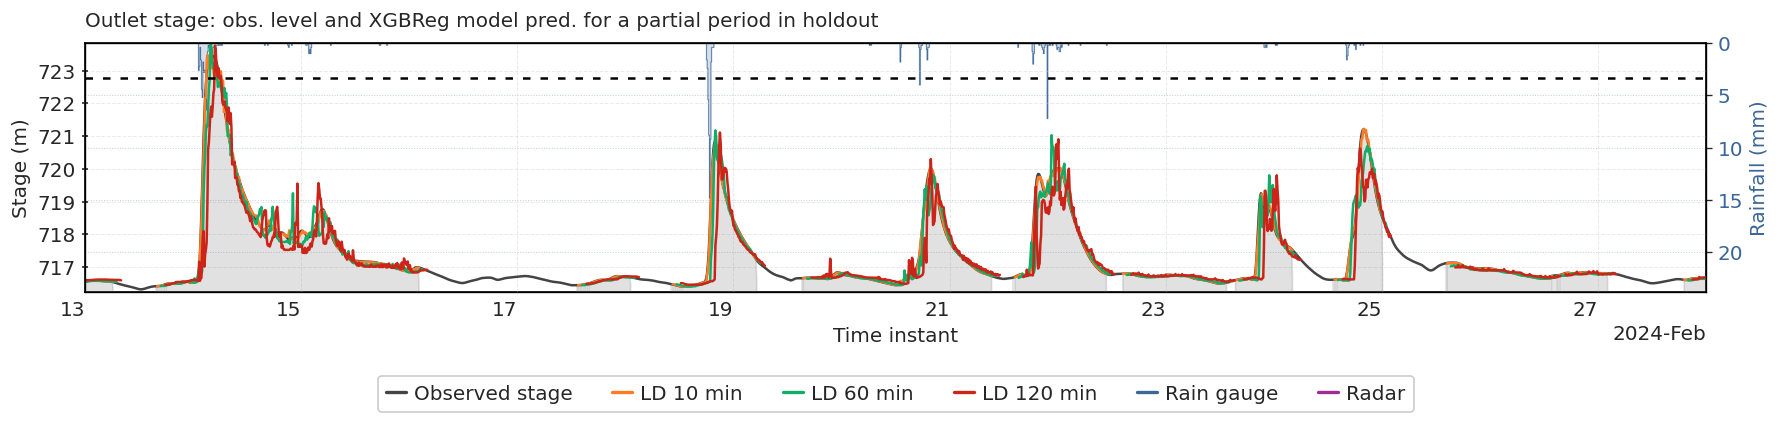

In [27]:
# =======================================
# Define output file name (PNG image) and
# plot-range (within the holdout period)

fileName = plots_dir + f"Series_Compare_{model_tag}.png"

xlim = [ pd.Timestamp('2024-02-13'),
         pd.Timestamp('2024-02-28') ]

plotName0 = f"Outlet stage: obs. level and {model_tag} model pred."

plotName = plotName0 + " for a partial period in holdout"

# =============================================
# Set plot-mode (rain gauge or radar rainfall)
# and run the function with all custom features:

rkey = False #( switch between rain gauge and radar )

if rkey:
    ##
    rainf_col = radar_cell
else:
    rainf_col = plu413

plot_series_comparison(
    dfrm1 = dataFrm1,
    dfrm2 = dataFrm2,
    dfrm3 = dataFrm3,
    dfRef = dfbase,
    time_col = time_col,
    pred_col = data1_col,
    true_col = data2_col,
    rain_col = rainf_col,
    lvls_col = flu413,
    plot_range = xlim,
    fname = fileName,
    with_radar = rkey,
    title = plotName,
    fill_frm = "dfrm1")

<div style="max-width: 900px; text-align: justify;">

* We can find the events within the holdout period where intense rainfall on the TRW causes flood-warning conditions on the river stage (level surpassing the 722.779 m
threshold) at the station 413 by means of the function "detect_warning_intervals" defined in the next cell:

</div>

In [28]:
# Function to find events (time intervals) where the input
# stage series exceeds a given threshold value, other opt.
# allow the configuration of the output list of tuples:

def detect_warning_intervals(input_dat, level_col, temporal_col,
                             threshold, limit_val, delta_days,
                             exact_duration_days):
    """
    Detect water-level warning intervals around exceedances.
    
    Parameters
    ----------
    input_dat : DataFrame
        Must contain columns [time_col] and [col_lvl]
    col_lvl : str
        Column name with water levels (e.g., 'flu413')
    time_col : str
        Timestamp column name
    threshold : float
        Exceedance threshold (e.g., 722.779)
    limit_val : float
        Minimum value required to confirm peak event (e.g., 720.000)
    delta_days : float
        +/- window (days) added around each threshold exceed
    exact_duration_days : float
        Final fixed interval size (days), symmetric around midpoint

    Returns
    -------
    event_range : list of (start, end) tuples
        Post-processed raw intervals based on threshold
    peak_range : list of (start, end) tuples
        Narrowed intervals based on limit_val behavior
    """
    
    df = input_dat.copy()
    
    # 1) Identify exceedances

    exceed_mask = df[level_col] > threshold

    exceed_times = df.loc[exceed_mask, temporal_col]

    if exceed_times.empty:
        ##
        return [], []

    # 2) Build raw ranges ±delta

    delta = pd.Timedelta(days=delta_days)

    raw_ranges = [(t - delta, t + delta) for t in exceed_times]

    # 3) Merge overlapping ranges

    raw_ranges.sort(key=lambda x: x[0])

    merged = [raw_ranges[0]]

    for start, end in raw_ranges[1:]:
        ##
        prev_start, prev_end = merged[-1]

        if start <= prev_end:
            ##
            merged[-1] = (prev_start, max(prev_end, end))
        else:
            merged.append((start, end))

    event_range = merged.copy()

    # 4) Adjust each merged interval to exact fixed duration

    exact_duration = pd.Timedelta(days=exact_duration_days)

    half_dur = exact_duration / 2

    event_range_fixed = []

    for start, end in event_range:
        ##
        center = start + (end - start) / 2

        new_start = center - half_dur
        new_end   = center + half_dur

        # test rainfall > 1 within this window

        mask = (df[temporal_col] >= new_start) & \
               (df[temporal_col] <= new_end)

        df_window = df.loc[mask, level_col]

        if (df_window > 1.0).any():
            ##
            event_range_fixed.append((new_start, new_end))

    event_range = event_range_fixed.copy()

    # 5) Filter by limit_val behavior around the center

    peak_range = []

    margin = pd.Timedelta(hours=1)

    for start, end in event_range:
        ##
        search_start = start + margin
        search_end   = end - margin

        center_time = start + (end - start) / 2

        # index lookups

        center_idx = df.index[df[temporal_col].searchsorted(center_time)]
        idx_start  = df.index[df[temporal_col].searchsorted(search_start)]
        idx_end    = df.index[df[temporal_col].searchsorted(search_end)]

        i_left, i_right = center_idx, center_idx

        # expand left
        while i_left > idx_start and df.at[i_left, level_col] >= limit_val:
            i_left -= 1

        # expand right
        while i_right < idx_end and df.at[i_right, level_col] >= limit_val:
            i_right += 1

        t1 = df.at[i_left  + 1, temporal_col]
        t2 = df.at[i_right - 1, temporal_col]

        peak_range.append((t1, t2))

    return event_range, peak_range

In [29]:
# Here we use the above function to find the events:

event_range, peak_range = detect_warning_intervals(
    input_dat = dfbase,
    level_col = flu413,
    temporal_col = time_col,
    threshold = 722.779, #( default warning value )
    limit_val = 720.000, #( min. value for warning windows )
    delta_days = 1.0, exact_duration_days = 2.0
)

<div style="max-width: 900px; text-align: justify;">

* Let us focus on the first event on February 14, 2024. Along with the confirmed radar-gauge agreement during this episode, it is one of the few major occurrences in the holdout period that is representative of a typical flash flood, exhibiting a clear two-phase stage response: a rapid rise – surpassing the 722.779 m threshold (set by the local authorities) that signals flood-warning conditions – driven by intense rainfall, followed by a slower recession phase. Below we use the "event_range" list to plot the time-series of stage measurements and predicted values:

</div>

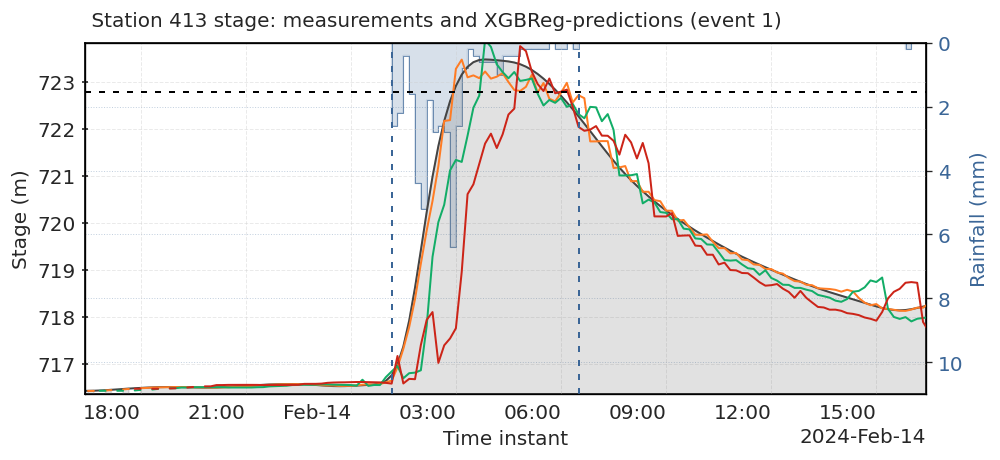

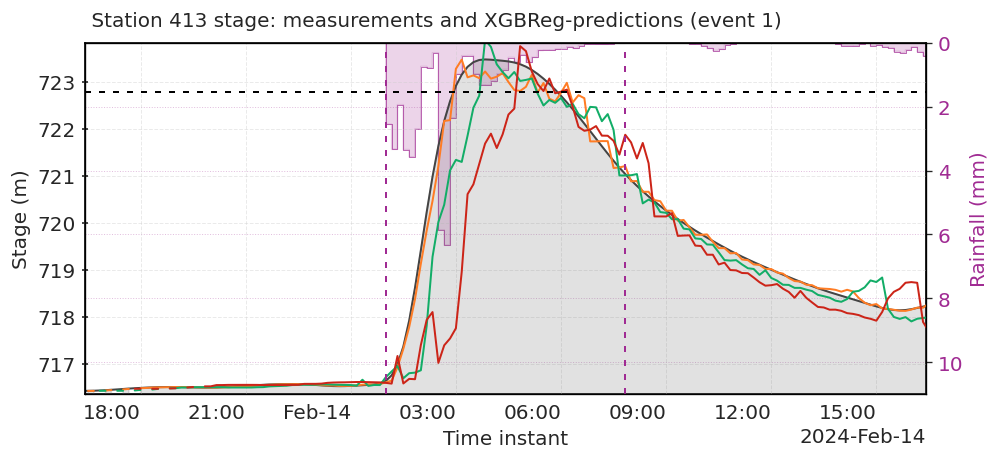

In [30]:
# ===================
# Select first event: (index = 0, id = 1)

i0 = 0; id = i0 + 1

delta = pd.Timedelta(days = -0.5)

tlim = [ event_range[i0][0] - delta,
         event_range[i0][1] + delta ]

# ============================================================
# Plot series for selected event using different event-ranges:
#
# Info: t1 & t2 set the event-range as being the time interval
# with rainfall signals from the rain gauge or the radar field,
# the function computes the NSE for the stage data within this
# range (see the "nse_values" also generated as output);

baseName = f" Station 413 stage:"

baseName += f" measurements and {model_tag}-predictions"

plotName = baseName + f" (event {id})"

# Stage and rainfall (rain gauge - station 413) time-series:

t1 = pd.Timestamp('2024-02-14 01:10:00') # Rainfall from
t2 = pd.Timestamp('2024-02-14 06:30:00') # rain gauge;

filename = plots_dir + f"Series_Check1_event{id}_{model_tag}.png"

nse_values = plot_series_comparison(
    dfrm1 = dataFrm1,
    dfrm2 = dataFrm2,
    dfrm3 = dataFrm3,
    dfRef = dfbase,
    time_col = time_col,
    pred_col = data1_col,
    true_col = data2_col,
    rain_col = plu413,
    lvls_col = flu413,
    plot_range = tlim,
    fname = filename,
    title = plotName,
    tstamp1 = t1, 
    tstamp2 = t2,
    zoom_pmode = True,
    hide_lbox = True,
    hide_NSE_table = True,
    hide_plot = False,
    fill_frm = "dfrm1"
)

# Stage and rainfall (nearest radar cell) time-series:

t1 = pd.Timestamp('2024-02-14 01:00:00')
t2 = pd.Timestamp('2024-02-14 07:50:00')

filename = plots_dir + f"Series_Check2_event{id}_{model_tag}.png"

nse_values = plot_series_comparison(
    dfrm1 = dataFrm1,
    dfrm2 = dataFrm2,
    dfrm3 = dataFrm3,
    dfRef = dfbase,
    time_col = time_col,
    pred_col = data1_col,
    true_col = data2_col,
    rain_col = radar_cell,
    lvls_col = flu413,
    plot_range = tlim,
    fname = filename,
    title = plotName,
    tstamp1 = t1, 
    tstamp2 = t2,
    with_radar = True,
    zoom_pmode = True,
    hide_lbox = True,
    hide_NSE_table = True,
    hide_plot = False,
    fill_frm = "dfrm1"
)

<div style="max-width: 900px; text-align: justify;">

**Analysis of the time-series:** 

The above plots show the time-series for the observed stage and the predicted values generated by the 3 models for lead-times 10, 60 and 120 minutes. We see that all of them successfully replicate the rapid increase of nearly 7 m during the stage rise, and that all predictions exceed the warning threshold (horizontal dashed line), indicating that an operational alert would be triggered. Since the models were trained to forecast using only information available at the current time, the predicted series naturally exhibit some lag and occasional sharp rises, as they associate future stage increases with the rainfall signals available at the moment of prediction. For the shortest lead time (10 min), all models accurately detect the start of the hydrograph’s rise. For longer lead times (60 and 120 min), a consistent positive lag becomes clear. This pattern arises from the models' dependence on past rainfall to predict future stages. The combined effects of this smoothing and reliance on past rainfall result in a delayed response. This behavior is well documented in the literature. In this study, models based on rain gauge measurements tend to produce sharper peaks (reflecting the higher temporal variability of point-scale observations) and may occasionally overestimate the peak stage, with this effect being most evident in the case of LinearSVR models. During the recession phase of the hydrograph, all models consistently reproduced the stage decline. XGBRegressor models produced a stepwise decay pattern, which is consistent with the piecewise-constant behavior inherent to decision-tree-based algorithms, and the fluctuations in the predicted hydrograph arises from the temporal variability at the point scale from rain gauge inputs.

</div>

<div style="max-width: 900px; text-align: justify;">

* To further evaluate the agreement between predicted and observed stage values, we make a scatter plot showing the predicted versus observed stage values from station 413 for time points within the holdout period. The function below is used to produce a scatter plot for models trained to forecast lead times of 10, 60, and 120 minutes, where the gray shaded band represents a $\pm 1.0$ m deviation from the black dashed 1:1 reference line:

</div>

In [31]:
def scatter_r2(
    data_frames,
    time_col: str = "time",
    pred_col: str = "pred",
    true_col: str = "true",
    labels: list = None,
    colors: list = None,
    fgname: str  = None,
    y_fixed_range: tuple = None,
    data_range: tuple = None,
    band_width: float = None,
    band_alpha: float = 0.10,
    hide_plot: bool = False,
    hide_lbox: bool = False,
):
    """
    Scatter plot comparing predicted vs observed values
    for one or more datasets. Computes per-dataset R²
    (coefficient of determination) and p-value
    from a linear regression fit. """

    # ===============
    # Normalize input

    if not isinstance(data_frames, (list, tuple)):
        ##
        data_frames = [data_frames]

    n = len(data_frames)

    if labels is None:
        ##
        labels = [f"Set {i+1}" for i in range(n)]
        
    if colors is None:
        ##
        colors = ["#FF7C24", "#12AD67", "#CC2418", "#C20AA3"]  

    # ==============
    # Customize plot

    fig, ax = plt.subplots(figsize = (4, 5))

    # =============================================
    # Initialize lists and prepare for calculations

    z_base = 10

    r2_values = []
    r_values  = []
    p_values  = []

    # ==================
    # Loop over datasets

    for df, lbl, col in zip(data_frames, labels, colors):
        ##
        dfi = df.copy()

        # Filter by time

        if data_range is not None:
            ##
            t1, t2 = data_range

            mask = (dfi[time_col] >= t1) & (dfi[time_col] <= t2)

            dfi = dfi.loc[mask]

        # Remove NaNs

        dfi = dfi[[true_col, pred_col]].dropna()

        y_true = dfi[true_col].values
        y_pred = dfi[pred_col].values

        # Compute R²

        r2 = r2_score(y_true, y_pred)
        
        r2_values.append(r2)

        # Compute correlation and p-value

        r, p = pearsonr(y_true, y_pred)

        r_values.append(r)
        p_values.append(p)

        # Scatter

        ax.scatter(y_true, y_pred, s=6, alpha=0.4,
                   label=f"{lbl}", color=col, zorder=z_base)
        
        z_base -= 1

    # ===============
    # Reference range

    all_true = np.concatenate([
        df[[true_col]].dropna().values.ravel()
        for df in data_frames
    ])

    x_line = np.linspace(all_true.min() - 1,
                         all_true.max() + 1, 200)

    # ==============
    # Deviation band

    if band_width is not None:
        ##
        ax.fill_between(x_line, x_line - band_width, 
                        x_line + band_width, color="black", alpha=band_alpha, 
                        label=f"±{band_width:.2f} m deviation", zorder=2)

    # ========
    # 1:1 line

    line, = ax.plot(x_line, x_line, color="black", linewidth=1.0, zorder=20)
    
    line.set_dashes([3, 4])

    ax.set_xlabel("Observed stage (m)")
    ax.set_ylabel("Predicted stage (m)")

    ax.set_title("Scatter: predicted × observed")

    ax.set_xlim(all_true.min() - 0.2, all_true.max() + 0.2)

    if y_fixed_range is not None:
        ##
        ax.set_ylim(*y_fixed_range)

    ax.grid(alpha=0.3)

    # ===================
    # Legend construction

    if not hide_lbox:
        ##
        leg = ax.legend(
            frameon=True, fancybox=True, framealpha=1.0,
            shadow=False, loc='upper center',
            bbox_to_anchor=(0.5, -0.18), ncol=5,
            handlelength=1.2, handleheight=1.0,
            handletextpad=0.3, fontsize=12,
            edgecolor="gray", facecolor="white",
        )

        # Make legend lines thicker

        for h in leg.get_lines():
            ##
            h.set_linewidth(2.5)

    plt.tight_layout()

    if fgname: plt.savefig(fgname, bbox_inches="tight")

    if not hide_plot: plt.show()

    plt.close(fig)

    # ===================
    # Return both metrics

    df_results = pd.DataFrame({
        "Model type" : labels,
        "R2 value  " : r2_values,
        "Pr value  " : r_values,
        "p-value   " : p_values
    })

    return df_results

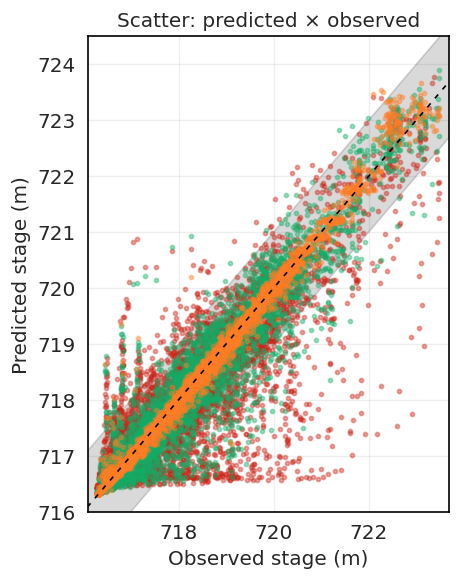

,Model type,R2 value,Pr value,p-value
0,LD 10 min,0.994505,0.997327,0.0
1,LD 60 min,0.938752,0.969066,0.0
2,LD 120 min,0.809369,0.899996,0.0


In [32]:
# ===============================================
# Make scatter plot: observed stage X pred. stage

scatter_r2(
    data_frames = [dataFrm1, dataFrm2, dataFrm3], 
    colors      = ["#FF7C24", "#12AD67", "#CC2418"],
    labels      = ["LD 10 min", "LD 60 min", "LD 120 min"],
    fgname      = plots_dir + "scatter_all_leads.png",
    pred_col    = data1_col,
    true_col    = data2_col,
    y_fixed_range = (716, 724.5),
    band_width    = 1.00,
    band_alpha    = 0.15,
    hide_lbox = True
)

<div style="max-width: 900px; text-align: justify;">

**Analysis of the scatter plot:** 

Overall, the above scatter plot shows distributions that appear mostly within the 1-meter deviation band (shaded area represented by the 1:1 line), indicating that the predictions aligned closely with the observed series. These observations are supported quantitatively by the coefficient of determination ($R^{2}$), calculated for each model based on the observed stages (see table below the scatter plot). The consistently high $R^{2}$ values demonstrate strong predictive ability for XGBRegressor models. The hypothesis tests produce very small $p$-values ($<10^{-6}$), but this simply indicates that the correlation between predicted and observed stages is significantly different from zero. However, such statistical significance provides little insight in large datasets, and the effect size ($R^{2}$) is more meaningful, as it directly measures the strength of the linear relationship and better characterizes model performance.

</div>

<div style="max-width: 900px; text-align: justify;">

#### **Statistical analysis of the stage distributions in the training and holdout sets:**

The ML4FF framework was used to obtain optimized LinearSVR and XGBRegressor models for lead times of 10, 60, and 120 minutes. To assess their performance under unseen conditions, the complete predicted stage series was analyzed using the holdout dataset. In comparison with the dataset used in the training-validation-test phase, with $N = 138128$ stage measurements totaling 959 days within a 3107-day calendar period, the holdout dataset has $N = 19733$ stage measurements totaling 137 days (546-day calendar period). Below, we show that it offered a statistically representative foundation for assessing the trained ML models under unseen operating conditions. In doing so, we use the "stats_comparison" function below to produce two plots comparing the stage cumulative distribution function of both datasets and also the general statistics (average, median, min/max & prob. distribution). 

</div>

In [33]:
# This function plots the cumulative distribution function (CDF)
# of two input data-sets and also their violin plots showing the
# average, median, min/max & prob. distribution for binned values,
# and as an additional output the Wasserstein-distance is computed;

def stats_comparison(dfrm1: pd.DataFrame,
                     dfrm2: pd.DataFrame,
                     datcol: str = "FLUm_413",
                     x_name: str = "Stage (m)",
                     labelLst: tuple = ("Sample 1", "Sample 2"),
                     colorLst: tuple = ("#027568", "#E53F9A"),
                     figName: str  = None,
                     add_leg: bool = True,
                     downSmp: bool = False):
    
    # ---- Data ----

    data1 = dfrm1[datcol].dropna().values
    data2 = dfrm2[datcol].dropna().values

    if downSmp:
        ##
        data1 = downsample_dataset(data1, maxn=1000)
        data2 = downsample_dataset(data2, maxn=1000)

    # ---- ECDFs ----

    ecdf1 = ECDF(data1)
    ecdf2 = ECDF(data2)

    # unified grid for smooth curves

    x_min = min(data1.min(), data2.min())
    x_max = max(data1.max(), data2.max())

    xx = np.linspace(x_min, x_max, 2000)

    y1 = ecdf1(xx)
    y2 = ecdf2(xx)

    # ---- W-Test (with normalization) ----
    #
    # Comment: normalization is done based on the first
    # data-set, i.e., the second one is normalized with
    # the same min/max features to avoid modifications
    # on the CDFs properties and make comparison fair,
    # and also to make the W-distance dimensionless
    # & comparable with a significance level alpha;

    maxVal = data1.max()
    minVal = data1.min()

    dataRange = maxVal - minVal

    ndata1 = (data1 - minVal) / dataRange
    ndata2 = (data2 - minVal) / dataRange

    wd = wasserstein_distance(ndata1, ndata2)

    # ---- Prepare Plot Area ----

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    fig.subplots_adjust(hspace=0.5)

    # ---- CDFs Plot ----

    ax = axes[0]

    ax.plot(xx, y1, lw=2.5, color=colorLst[0], label=labelLst[0], linestyle='-' )
    ax.plot(xx, y2, lw=2.5, color=colorLst[1], label=labelLst[1], linestyle='--')

    ax.set_xlabel(x_name)

    ax.set_ylabel("CDF")

    ax.set_title("CDF Comparison")

    ax.grid(True, alpha=0.3)

    if add_leg:
        ##
        leg = ax.legend(
            frameon=True, fancybox=True, framealpha=1.0,
            shadow=False, loc='upper center',
            bbox_to_anchor=(0.5, -0.22), ncol=5,
            handlelength=2.0, handleheight=1.0,
            handletextpad=0.3, fontsize=12,
            edgecolor="gray", facecolor="white",
        )

        # Make legend lines thicker

        for h in leg.get_lines():
            ##
            h.set_linewidth(2.5)

    # ---- Violin Plot ----
    
    ax = axes[1] # Set axis (sub-plot) and
                 # prepare data-frame for SNS-code

    df = pd.DataFrame({
        "value": np.concatenate([data1, data2]),
        "Datasets": np.repeat(labelLst, [len(data1), len(data2)])})

    vp = sns.violinplot(
        data=df, x="Datasets", y="value", hue="Datasets", # Build violins
        palette=colorLst, ax=ax, cut=0,
        inner=None, legend=False)

    for coll in ax.collections: # Make violins transparent
        ##
        coll.set_alpha(0.3)
    
    stats = df.groupby("Datasets")["value"].agg( # Compute statistics
        median="median", mean="mean",
        min="min", max="max")
    
    def short_hline(ax, x, y, w=0.15, **kwargs):
        ##
        ax.plot([x - w/2, x + w/2], [y, y], **kwargs) # Short horiz. line
   
    def vert_line(ax, xpos, y0, y1, color, lw=2):
        ##
        ax.plot([xpos, xpos], [y0, y1], color=color, lw=lw, zorder=3) # Vert. line

    for i, grp in enumerate(labelLst): # Custom lines
        ##
        ymed  = stats.loc[grp, "median"]
        ymean = stats.loc[grp, "mean"]
        ymin  = stats.loc[grp, "min"]
        ymax  = stats.loc[grp, "max"]

        ## Horizontal lines
        ##
        short_hline(ax, i, ymed,  w=0.15, color="#FFFFFF", linewidth=2)
        short_hline(ax, i, ymean, w=0.08, color="#3F3F3F", linewidth=2)
        short_hline(ax, i, ymin,  w=0.08, color=colorLst[i], linewidth=2)
        short_hline(ax, i, ymax,  w=0.08, color=colorLst[i], linewidth=2)

        print(f" > {labelLst[i]} : Median = {ymed}, Mean = {ymean}, Min/Max = {ymin}/{ymax}")

        ## Vertical line connecting min → max
        ##
        vert_line(ax, i, ymin, ymax, color=colorLst[i], lw=2)

    ax.set_ylabel(x_name)

    ax.set_title("Violin Plot: distribution comparison")
    
    ax.grid(True, alpha=0.3)

    # ---- Save figure and print W-D statistic ----

    if figName:
        ##
        fig.savefig(figName, bbox_inches="tight")

    print(f"\n > Wasserstein-Distance = {float(wd)}")

    return 

* Below, we prepare the stage datasets that will be used as inputs for the above function:

In [34]:
t0 = pd.Timestamp("2015-04-01 00:00:00")

mask1 = (dataML4FF[time_col] >= t0) & (dataML4FF[time_col] <= holdout_range[0][0])

mask2 = (dataML4FF[time_col] >= holdout_range[0][0]) & (dataML4FF[time_col] <= holdout_range[0][1])

dataTrain = dataML4FF.loc[mask1, [time_col, flu413]].copy()
dataHoldt = dataML4FF.loc[mask2, [time_col, flu413]].copy()

* The function is now called using the "FLUm_413" as input data columns (stage at the station 413):

 > Training : Median = 716.7330335238327, Mean = 717.1324553174193, Min/Max = 716.2111521594292/724.5093711551895
 > Holdout  : Median = 716.7109522382792, Mean = 717.1686891999716, Min/Max = 716.2863997360975/723.4811952475202

 > Wasserstein-Distance = 0.006972469850925422


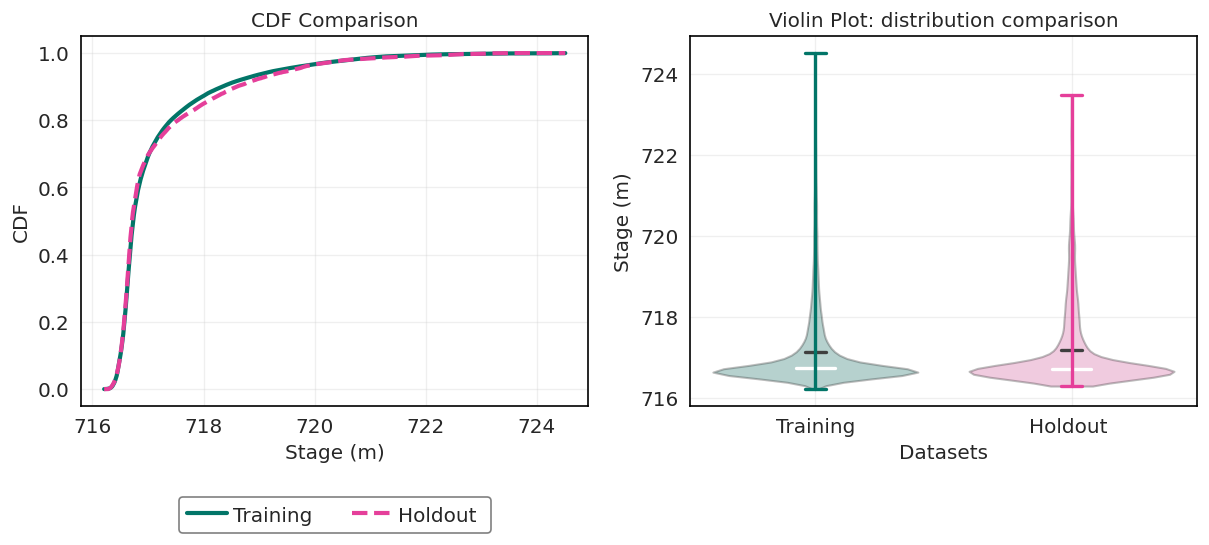

In [35]:
stats_comparison(
    dfrm1 = dataTrain,
    dfrm2 = dataHoldt,
    datcol = flu413,
    colorLst = ("#027568", "#E53F9A"),    
    labelLst = ["Training", "Holdout "],
    figName = plots_dir + "cdf_train_holdout.png", 
)

<div style="max-width: 900px; text-align: justify;">

**Analysis of the above results:**

The plots and statistical results above provide strong evidence of our claim, which is further confirmed by the Wasserstein distance ($W$) which also computed by the "stats_comparison" function (see the results above the plot). This metric measures the minimal transport cost needed to convert one distribution into the other, it offers a robust and understandable way to compare empirical distributions and avoids the sensitivity problems that affect hypothesis-testing methods when $N$ is large. Using the standard dimensionless form with a significance level of $\alpha = 0.05$ and applying common scaling factors to normalize both datasets, the resulting value $W = 0.007 < \alpha$ indicates that the two-stage distributions are indeed very similar in overall shape.

</div>